In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings; warnings.filterwarnings("ignore")

from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima_process import ArmaProcess

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = [10, 7.5]

%matplotlib inline

In [2]:
df = pd.read_csv('air_pollution.csv', parse_dates=['date'])
df.set_index('date', inplace=True)
df.index = pd.date_range(start="2010-01-02 00:00:00", periods=len(df), freq="h")
df

,pollution_today,dew,temp,press,wnd_dir,wnd_spd,snow,rain
2010-01-02 00:00:00,129.0,-16,-4.0,1020.0,SE,1.79,0,0
2010-01-02 01:00:00,148.0,-15,-4.0,1020.0,SE,2.68,0,0
2010-01-02 02:00:00,159.0,-11,-5.0,1021.0,SE,3.57,0,0
2010-01-02 03:00:00,181.0,-7,-5.0,1022.0,SE,5.36,1,0
2010-01-02 04:00:00,138.0,-7,-5.0,1022.0,SE,6.25,2,0
...,...,...,...,...,...,...,...,...
2014-12-31 19:00:00,8.0,-23,-2.0,1034.0,NW,231.97,0,0
2014-12-31 20:00:00,10.0,-22,-3.0,1034.0,NW,237.78,0,0
2014-12-31 21:00:00,10.0,-22,-3.0,1034.0,NW,242.70,0,0
2014-12-31 22:00:00,8.0,-22,-4.0,1034.0,NW,246.72,0,0


In [3]:
df.drop(['dew', 'temp', 'temp',
       'press', 'wnd_spd','snow','rain','wnd_dir'], axis=1, inplace=True)

In [4]:
df

,pollution_today
2010-01-02 00:00:00,129.0
2010-01-02 01:00:00,148.0
2010-01-02 02:00:00,159.0
2010-01-02 03:00:00,181.0
2010-01-02 04:00:00,138.0
...,...
2014-12-31 19:00:00,8.0
2014-12-31 20:00:00,10.0
2014-12-31 21:00:00,10.0
2014-12-31 22:00:00,8.0


In [5]:
df = df.resample('M').mean()

In [6]:
df

,pollution_today
2010-01-31,82.026389
2010-02-28,97.089286
2010-03-31,89.673387
2010-04-30,79.806944
2010-05-31,86.081989
2010-06-30,85.537500
2010-07-31,123.647849
2010-08-31,88.681452
2010-09-30,79.631944
2010-10-31,118.662634


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 60 entries, 2010-01-31 to 2014-12-31
Freq: ME
Data columns (total 1 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pollution_today  60 non-null     float64
dtypes: float64(1)
memory usage: 960.0 bytes


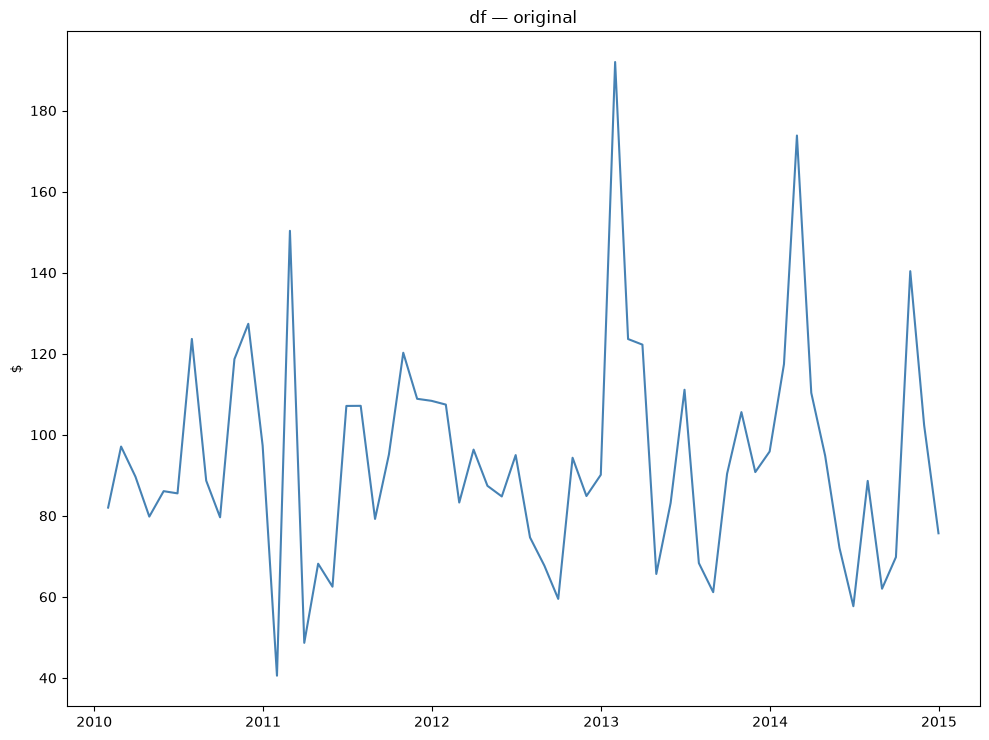

In [8]:
# Create the plot
fig, ax = plt.subplots()
ax.plot(df, color="steelblue")
ax.set_title("df — original")
ax.set_ylabel("$")
plt.tight_layout(); plt.show()

In [9]:
adf_result = adfuller(df)
adf_result
# Extract values manually from the tuple
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")
print(f"Critical Values: {adf_result[4]}")

ADF Statistic: -4.474441592520096
p-value: 0.00021864176653199787
Critical Values: {'1%': np.float64(-3.568485864), '5%': np.float64(-2.92135992), '10%': np.float64(-2.5986616)}


## Es estacionaria

In [10]:
#kpss_result =kpss(sia_diff['Value'], result_object=True) # el pvalor debe ser mayor que 0.05 para estacionalidad
#kpss_result
# Remove 'result_object=True'
from statsmodels.tsa.stattools import kpss
statistic, p_value, lags, critical_values = kpss(df['pollution_today'], regression='c', nlags='auto')

print(f"Test Statistic: {statistic}")
print(f"p-value: {p_value}")

Test Statistic: 0.04012265419545487
p-value: 0.1


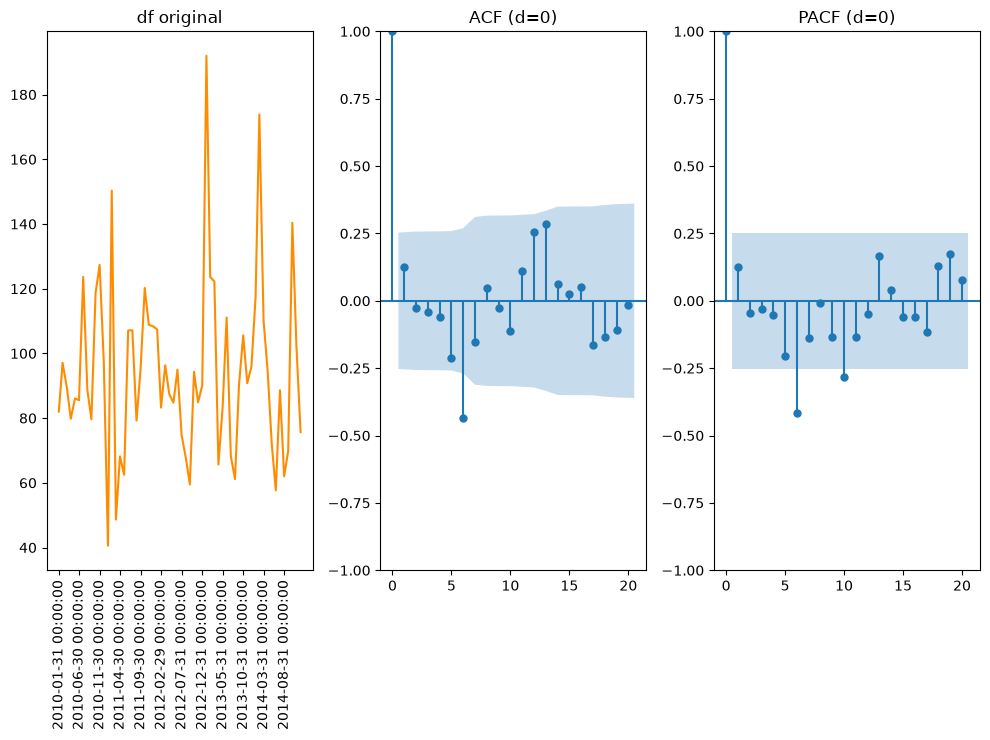

In [11]:
fig, axes = plt.subplots(1, 3)
axes[0].plot(df, color="darkorange")
axes[0].set_title("df original")
axes[0].set_xticks(ticks= df.index[::5],labels=df.index[::5],rotation=90)
plot_acf(df,  ax=axes[1], lags=20, title="ACF (d=0)")
plot_pacf(df, ax=axes[2], lags=20, title="PACF (d=0)", method="ywm")
plt.tight_layout(); plt.show()

In [12]:
df_diff = df.diff(6).dropna()

In [13]:
df_diff

,pollution_today
2010-07-31,41.621461
2010-08-31,-8.407834
2010-09-30,-10.041443
2010-10-31,38.855690
2010-11-30,41.295789
2010-12-31,11.795833
2011-01-31,-83.100806
2011-02-28,61.639977
2011-03-31,-30.977375
2011-04-30,-50.482079


In [14]:
adf_result = adfuller(df_diff)
adf_result
# Extract values manually from the tuple
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")
print(f"Critical Values: {adf_result[4]}")

ADF Statistic: -4.209808799886024
p-value: 0.0006341571697459535
Critical Values: {'1%': np.float64(-3.596635636000432), '5%': np.float64(-2.933297331821618), '10%': np.float64(-2.6049909750566895)}


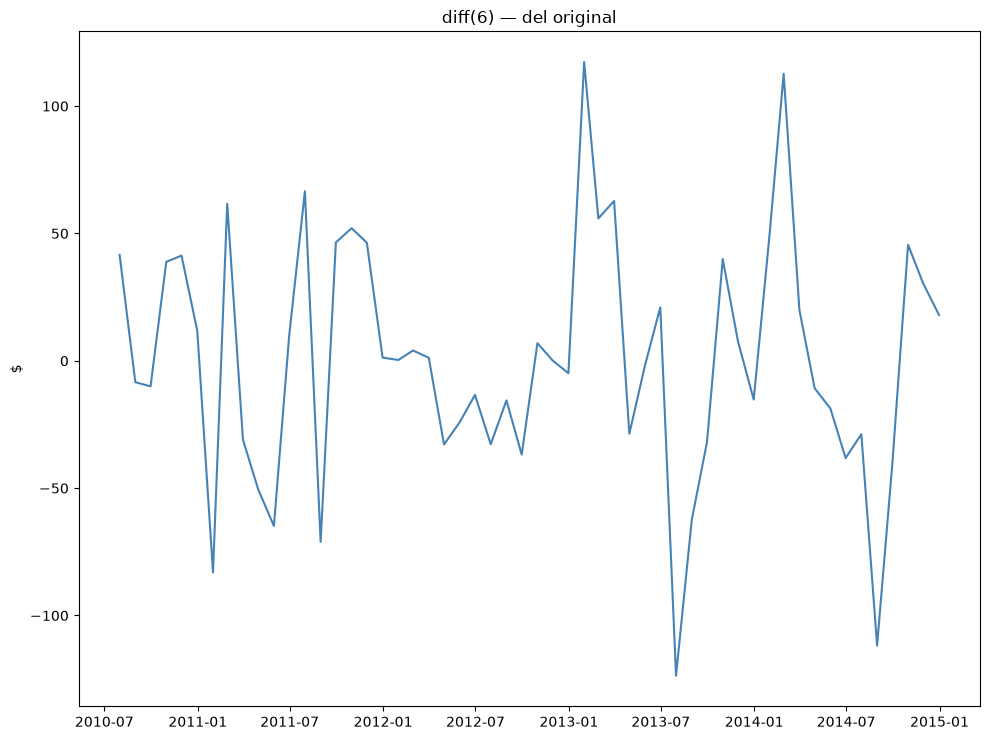

In [15]:
# Create the plot
fig, ax = plt.subplots()
ax.plot(df_diff, color="steelblue")
ax.set_title("diff(6) — del original")
ax.set_ylabel("$")
plt.tight_layout(); plt.show()

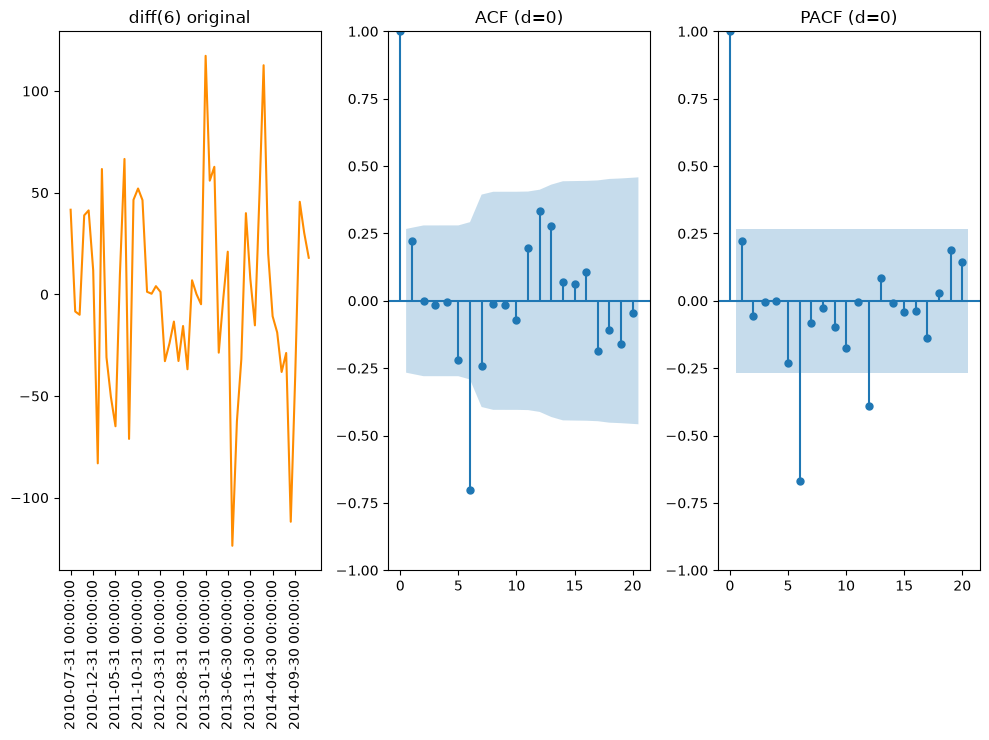

In [16]:
fig, axes = plt.subplots(1, 3)
axes[0].plot(df_diff, color="darkorange")
axes[0].set_title("diff(6) original")
axes[0].set_xticks(ticks= df_diff.index[::5],labels=df_diff.index[::5],rotation=90)
plot_acf(df_diff,  ax=axes[1], lags=20, title="ACF (d=0)")
plot_pacf(df_diff, ax=axes[2], lags=20, title="PACF (d=0)", method="ywm")
plt.tight_layout(); plt.show()

## Puede se d=0 pmax=1, qmax=1, D=1, Pmax=2, Qmax=1

In [17]:
import pmdarima as pm

# 'y' is your time series data
# Set 'seasonal=True' and 'm' to your seasonal period (e.g., 12 for monthly)
auto_model = pm.auto_arima(
    df,
    seasonal=True, m=6,
    test='adf',              # Use ADF test for stationarity
    stepwise=True,           # Use stepwise search to save time
    trace=True,              # Print the search progress
    information_criterion='bic', # Or 'bic',
    start_p=0, start_q=0, start_P=0,start_Q=0,
    max_p=2, max_q=2, d=1, D=1, max_P=3, max_Q=3
)

print(auto_model.summary())

Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,1,0)[6]             : BIC=588.635, Time=0.06 sec
 ARIMA(1,1,0)(1,1,0)[6]             : BIC=553.305, Time=0.05 sec
 ARIMA(0,1,1)(0,1,1)[6]             : BIC=inf, Time=0.07 sec
 ARIMA(1,1,0)(0,1,0)[6]             : BIC=585.754, Time=0.02 sec
 ARIMA(1,1,0)(2,1,0)[6]             : BIC=552.111, Time=0.07 sec
 ARIMA(1,1,0)(3,1,0)[6]             : BIC=554.319, Time=0.15 sec
 ARIMA(1,1,0)(2,1,1)[6]             : BIC=inf, Time=0.14 sec
 ARIMA(1,1,0)(1,1,1)[6]             : BIC=inf, Time=0.07 sec
 ARIMA(1,1,0)(3,1,1)[6]             : BIC=inf, Time=0.41 sec
 ARIMA(0,1,0)(2,1,0)[6]             : BIC=560.842, Time=0.04 sec
 ARIMA(2,1,0)(2,1,0)[6]             : BIC=550.873, Time=0.09 sec
 ARIMA(2,1,0)(1,1,0)[6]             : BIC=551.501, Time=0.07 sec
 ARIMA(2,1,0)(3,1,0)[6]             : BIC=553.555, Time=0.16 sec
 ARIMA(2,1,0)(2,1,1)[6]             : BIC=inf, Time=0.27 sec
 ARIMA(2,1,0)(1,1,1)[6]             : BIC=inf, Time=0.11 sec
 ARIMA

In [18]:
import statsmodels.api as sm
best_model = sm.tsa.SARIMAX(df, order=(2, 1, 0), #trend='c',
                seasonal_order=(2, 1, 0, 6)).fit()
print(best_model .summary())

                                     SARIMAX Results                                     
Dep. Variable:                   pollution_today   No. Observations:                   60
Model:             SARIMAX(2, 1, 0)x(2, 1, 0, 6)   Log Likelihood                -265.511
Date:                           Thu, 08 Oct 2026   AIC                            541.022
Time:                                   23:31:46   BIC                            550.873
Sample:                               01-31-2010   HQIC                           544.810
                                    - 12-31-2014                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6762      0.156     -4.336      0.000      -0.982      -0.371
ar.L2         -0.3263      0.184     -1.777

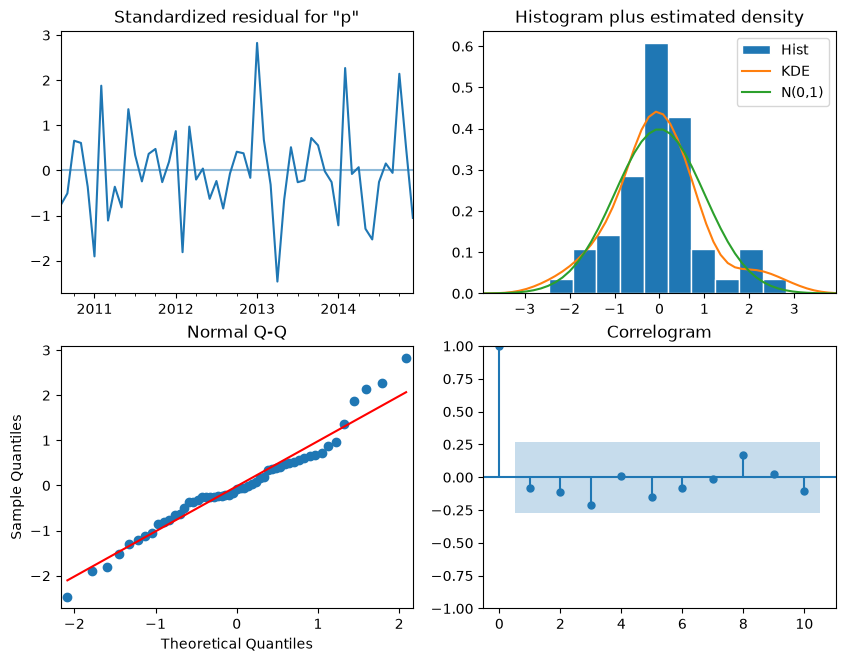

In [19]:
best_model.plot_diagnostics()
plt.show()

In [20]:
print(acorr_ljungbox(best_model.resid[1:], lags=[1, 2,3,4,5,6,7,8,9,10,15], return_df=True)) # deben ser mayores a 0.05

      lb_stat  lb_pvalue
1    0.540480   0.462234
2    1.844821   0.397560
3    4.468640   0.215105
4    4.775792   0.311086
5    5.727072   0.333688
6    6.674401   0.352010
7    6.675725   0.463406
8    8.454062   0.390418
9    8.605434   0.474463
10   9.635779   0.473007
15  16.718853   0.335947


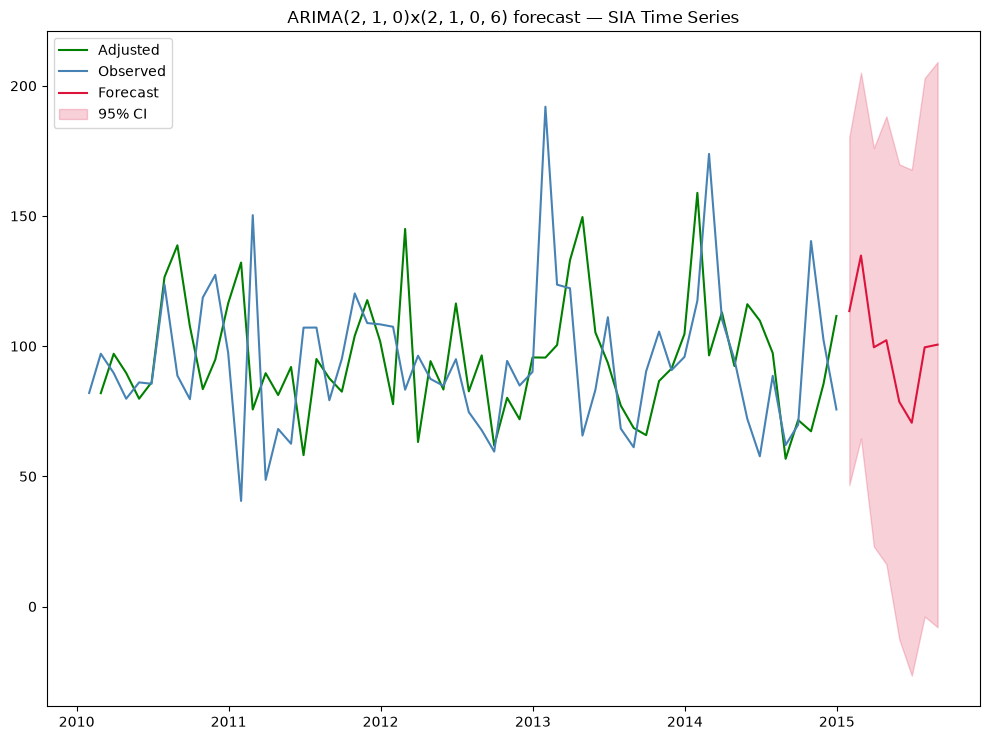

In [21]:
# 5. Forecast 136 periods 
# ---------------------------------------------------------------
steps = 8
fc   = best_model.get_forecast(steps=steps)
mean = fc.predicted_mean
ci   = fc.conf_int(alpha=0.05)

future_idx = pd.date_range(df.index[-1], periods=steps + 1, freq="ME")[1:]

fig, ax = plt.subplots()

ax.plot(best_model.fittedvalues[1:],label="Adjusted", color="green")
ax.plot(df, label="Observed", color="steelblue")
ax.plot(future_idx, mean, label="Forecast", color="crimson")
ax.fill_between(future_idx, ci.iloc[:, 0], ci.iloc[:, 1],
                color="crimson", alpha=0.2, label="95% CI")
ax.set_title("ARIMA(2, 1, 0)x(2, 1, 0, 6) forecast — SIA Time Series")
ax.legend(); plt.tight_layout(); plt.show()

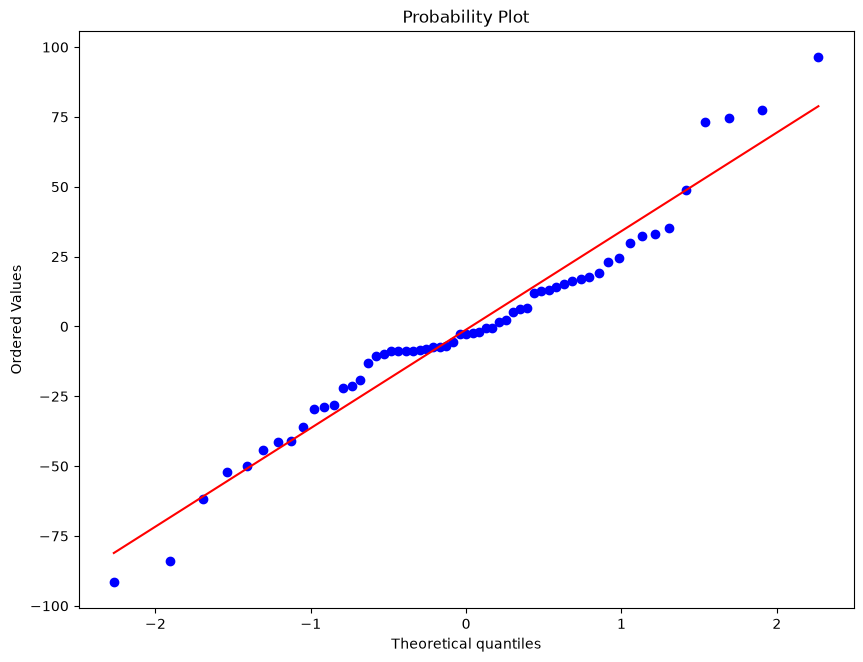

In [22]:
import scipy.stats as stats
stats.probplot(best_model.resid[1:],dist='norm', plot=plt)
plt.show()

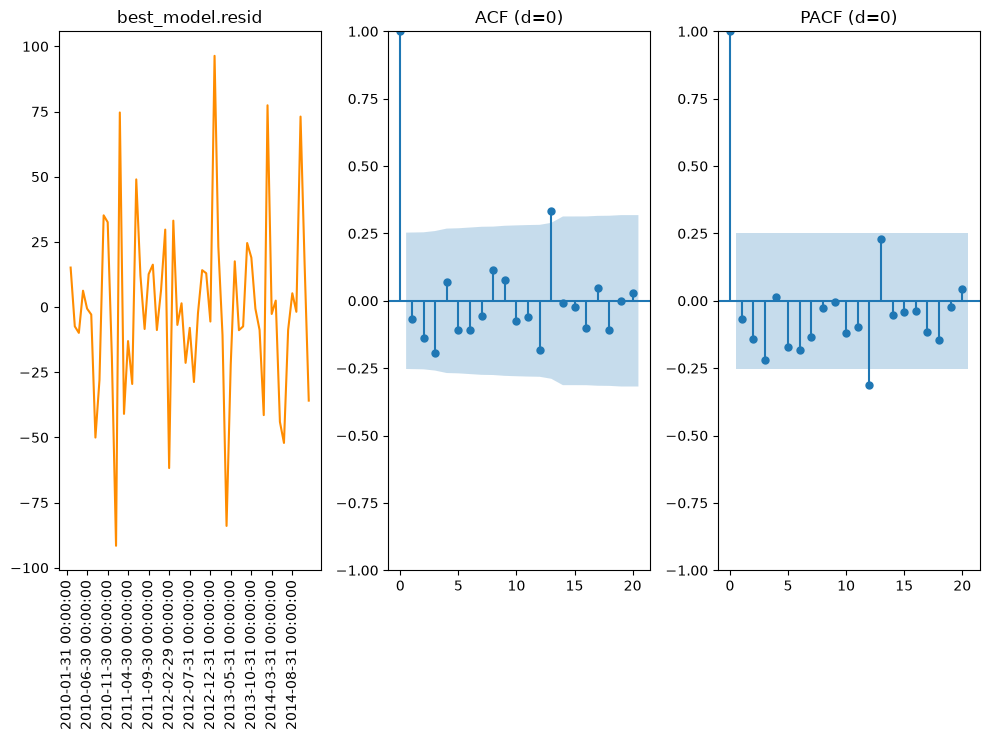

In [23]:
fig, axes = plt.subplots(1, 3)
axes[0].plot(best_model.resid[1:], color="darkorange")
axes[0].set_title("best_model.resid")
axes[0].set_xticks(ticks= best_model.resid.index[::5],labels=best_model.resid.index[::5],rotation=90)
plot_acf(best_model.resid,  ax=axes[1], lags=20, title="ACF (d=0)")
plot_pacf(best_model.resid, ax=axes[2], lags=20, title="PACF (d=0)", method="ywm")
plt.tight_layout(); plt.show()

## Box Cox

In [24]:
df_BoxCox , lam = stats.boxcox(df['pollution_today'])

In [25]:
lam

np.float64(0.05644947570908032)

In [26]:
df_BoxCox

array([5.00365403, 5.22089499, 5.11825106, 4.96850292, 5.06562859,
       5.05747026, 5.53611247, 5.10391851, 4.96569221, 5.48216122,
       5.57515263, 5.22414559, 4.11779858, 5.79391476, 4.34361247,
       4.76778492, 4.65789395, 5.34843569, 5.34876784, 4.95932033,
       5.19465495, 5.49946597, 5.36966076, 5.36369701, 5.3524705 ,
       5.0230058 , 5.21081302, 5.08513621, 5.04601153, 5.19255777,
       4.8834823 , 4.75906667, 4.59564167, 5.18358682, 5.04756149,
       5.12461159, 6.12074762, 5.53579091, 5.5210649 , 4.71991536,
       5.0215734 , 5.39616964, 4.77065074, 4.63026591, 5.12821941,
       5.3298225 , 5.1342506 , 5.20444253, 5.46862776, 5.98759265,
       5.38710363, 5.19051418, 4.83813704, 4.55668511, 5.10294201,
       4.6477541 , 4.79769833, 5.70316542, 5.28929791, 4.90075399])

In [27]:
df_BoxCox = pd.DataFrame(df_BoxCox,index=df.index)
df_BoxCox.columns=['Value']
df_BoxCox

,Value
2010-01-31,5.003654
2010-02-28,5.220895
2010-03-31,5.118251
2010-04-30,4.968503
2010-05-31,5.065629
2010-06-30,5.057470
2010-07-31,5.536112
2010-08-31,5.103919
2010-09-30,4.965692
2010-10-31,5.482161


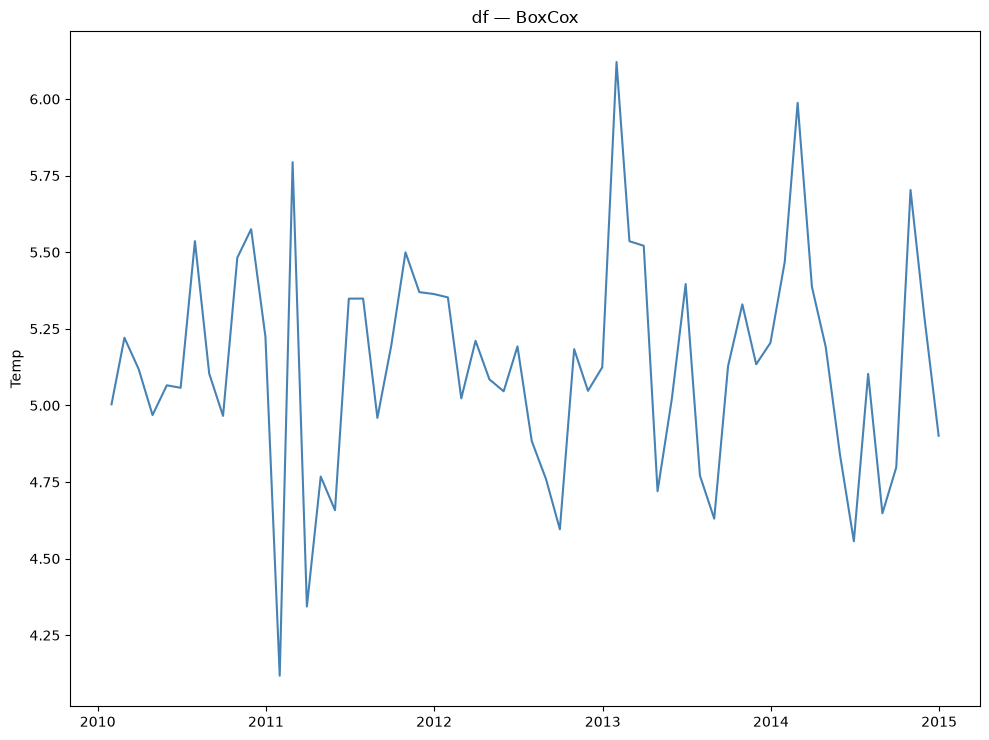

In [28]:
# Create the plot
fig, ax = plt.subplots()
ax.plot(df_BoxCox, color="steelblue")
ax.set_title("df — BoxCox")
ax.set_ylabel("Temp")
plt.tight_layout(); plt.show()

In [29]:
df_BoxCox_diff = df_BoxCox.diff(6).dropna()

In [30]:
adf_result = adfuller(df_BoxCox_diff)
adf_result
# Extract values manually from the tuple
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")
print(f"Critical Values: {adf_result[4]}")

ADF Statistic: -4.2043319708406175
p-value: 0.0006478627702808524
Critical Values: {'1%': np.float64(-3.596635636000432), '5%': np.float64(-2.933297331821618), '10%': np.float64(-2.6049909750566895)}


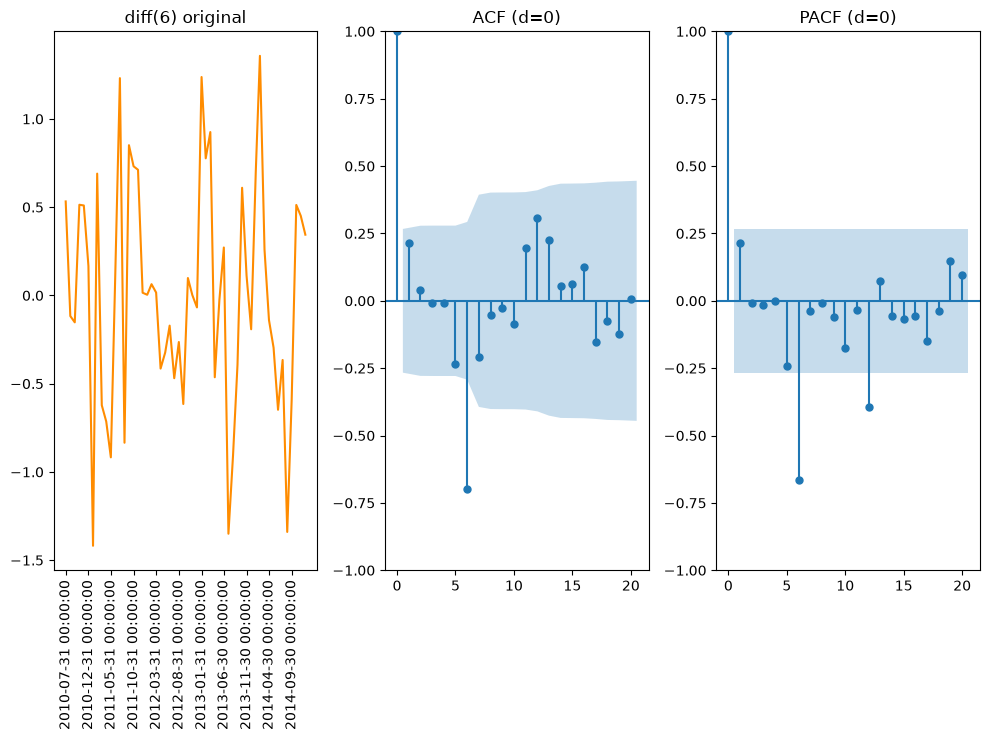

In [31]:
fig, axes = plt.subplots(1, 3)
axes[0].plot(df_BoxCox_diff, color="darkorange")
axes[0].set_title("diff(6) original")
axes[0].set_xticks(ticks= df_BoxCox_diff.index[::5],labels=df_BoxCox_diff.index[::5],rotation=90)
plot_acf(df_BoxCox_diff,  ax=axes[1], lags=20, title="ACF (d=0)")
plot_pacf(df_BoxCox_diff, ax=axes[2], lags=20, title="PACF (d=0)", method="ywm")
plt.tight_layout(); plt.show()

In [32]:
import pmdarima as pm

# 'y' is your time series data
# Set 'seasonal=True' and 'm' to your seasonal period (e.g., 12 for monthly)
auto_model = pm.auto_arima(
    df_BoxCox,
    seasonal=True, m=6,
    test='adf',              # Use ADF test for stationarity
    stepwise=True,           # Use stepwise search to save time
    trace=True,              # Print the search progress
    information_criterion='bic', # Or 'bic',
    start_p=0, start_q=0, start_P=0,start_Q=0,
    max_p=2, max_q=2, d=1, D=1, max_P=3, max_Q=3
)

print(auto_model.summary())

Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,1,0)[6]             : BIC=132.044, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[6]             : BIC=95.015, Time=0.04 sec
 ARIMA(0,1,1)(0,1,1)[6]             : BIC=inf, Time=0.12 sec
 ARIMA(1,1,0)(0,1,0)[6]             : BIC=127.573, Time=0.01 sec
 ARIMA(1,1,0)(2,1,0)[6]             : BIC=93.748, Time=0.06 sec
 ARIMA(1,1,0)(3,1,0)[6]             : BIC=95.163, Time=0.11 sec
 ARIMA(1,1,0)(2,1,1)[6]             : BIC=inf, Time=0.23 sec
 ARIMA(1,1,0)(1,1,1)[6]             : BIC=90.025, Time=0.07 sec
 ARIMA(1,1,0)(0,1,1)[6]             : BIC=inf, Time=0.08 sec
 ARIMA(1,1,0)(1,1,2)[6]             : BIC=inf, Time=0.15 sec
 ARIMA(1,1,0)(0,1,2)[6]             : BIC=91.606, Time=0.06 sec
 ARIMA(1,1,0)(2,1,2)[6]             : BIC=inf, Time=0.29 sec
 ARIMA(0,1,0)(1,1,1)[6]             : BIC=inf, Time=0.07 sec
 ARIMA(2,1,0)(1,1,1)[6]             : BIC=88.745, Time=0.07 sec
 ARIMA(2,1,0)(0,1,1)[6]             : BIC=inf, Time=0.14 sec
 ARIMA(2,1,0)(1,

In [33]:
import statsmodels.api as sm
best_model = sm.tsa.SARIMAX(df_BoxCox, order=(2, 1, 0), #trend='c',
                seasonal_order=(1, 1, 1, 6)).fit()
print(best_model .summary())

                                      SARIMAX Results                                      
Dep. Variable:                               Value   No. Observations:                   60
Model:             SARIMAX(2, 1, 0)x(1, 1, [1], 6)   Log Likelihood                 -34.447
Date:                             Thu, 08 Oct 2026   AIC                             78.894
Time:                                     23:31:51   BIC                             88.745
Sample:                                 01-31-2010   HQIC                            82.682
                                      - 12-31-2014                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7010      0.160     -4.385      0.000      -1.014      -0.388
ar.L2         -0.3309      

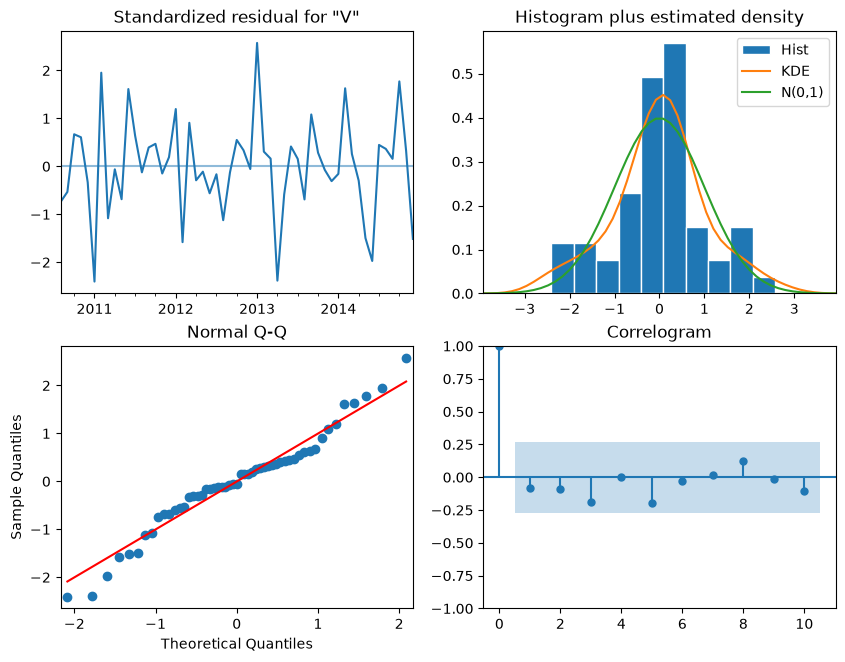

In [34]:
best_model.plot_diagnostics()
plt.show()

In [35]:
print(acorr_ljungbox(best_model.resid[1:], lags=[1, 2,3,4,5,6,7,8,9,10,15], return_df=True)) # deben ser mayores a 0.05

      lb_stat  lb_pvalue
1    0.007334   0.931752
2    0.205416   0.902391
3    2.451326   0.484152
4    2.477124   0.648737
5    3.405673   0.637706
6    4.365021   0.627407
7    5.203504   0.635144
8    6.698105   0.569527
9    6.731176   0.665085
10   6.916072   0.733344
15  11.300106   0.731045


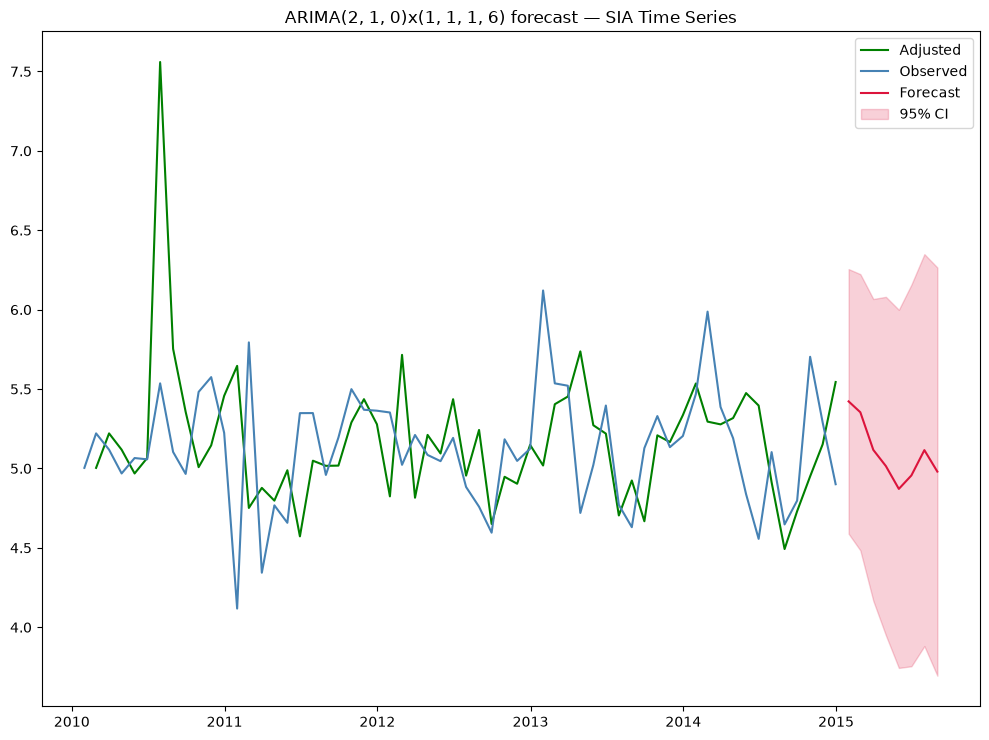

In [36]:
# 5. Forecast 136 periods 
# ---------------------------------------------------------------
steps = 8
fc   = best_model.get_forecast(steps=steps)
mean = fc.predicted_mean
ci   = fc.conf_int(alpha=0.05)

future_idx = pd.date_range(df.index[-1], periods=steps + 1, freq="ME")[1:]

fig, ax = plt.subplots()

ax.plot(best_model.fittedvalues[1:],label="Adjusted", color="green")
ax.plot(df_BoxCox, label="Observed", color="steelblue")
ax.plot(future_idx, mean, label="Forecast", color="crimson")
ax.fill_between(future_idx, ci.iloc[:, 0], ci.iloc[:, 1],
                color="crimson", alpha=0.2, label="95% CI")
ax.set_title("ARIMA(2, 1, 0)x(1, 1, 1, 6) forecast — SIA Time Series")
ax.legend(); plt.tight_layout(); plt.show()

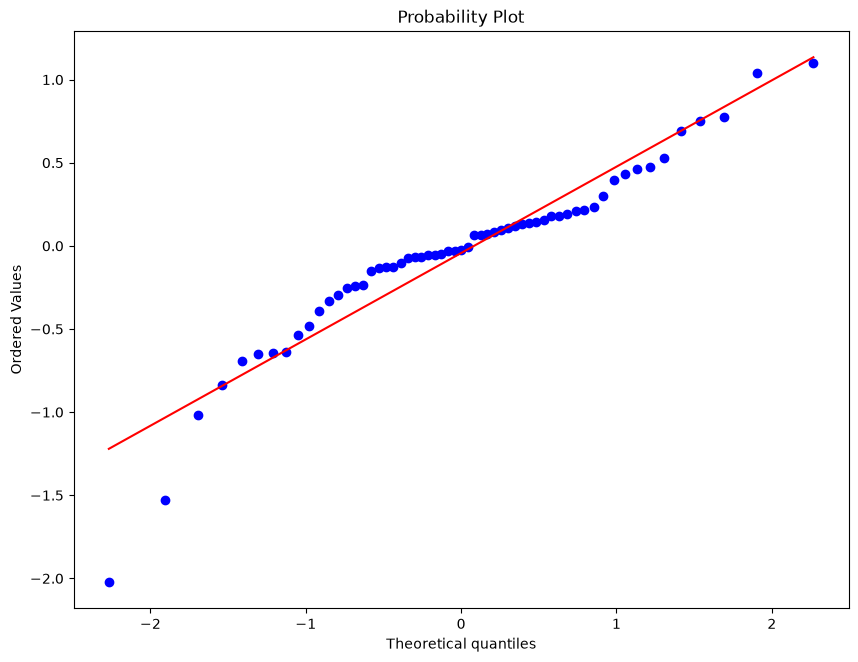

In [37]:
import scipy.stats as stats
stats.probplot(best_model.resid[1:],dist='norm', plot=plt)
plt.show()

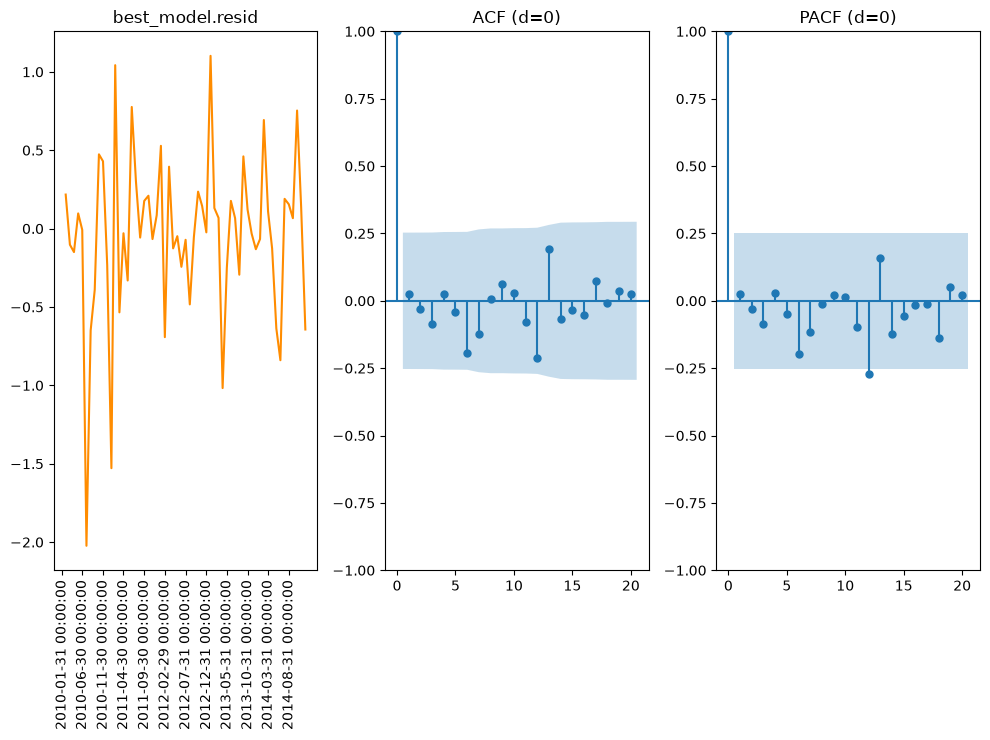

In [38]:
fig, axes = plt.subplots(1, 3)
axes[0].plot(best_model.resid[1:], color="darkorange")
axes[0].set_title("best_model.resid")
axes[0].set_xticks(ticks= best_model.resid.index[::5],labels=best_model.resid.index[::5],rotation=90)
plot_acf(best_model.resid,  ax=axes[1], lags=20, title="ACF (d=0)")
plot_pacf(best_model.resid, ax=axes[2], lags=20, title="PACF (d=0)", method="ywm")
plt.tight_layout(); plt.show()

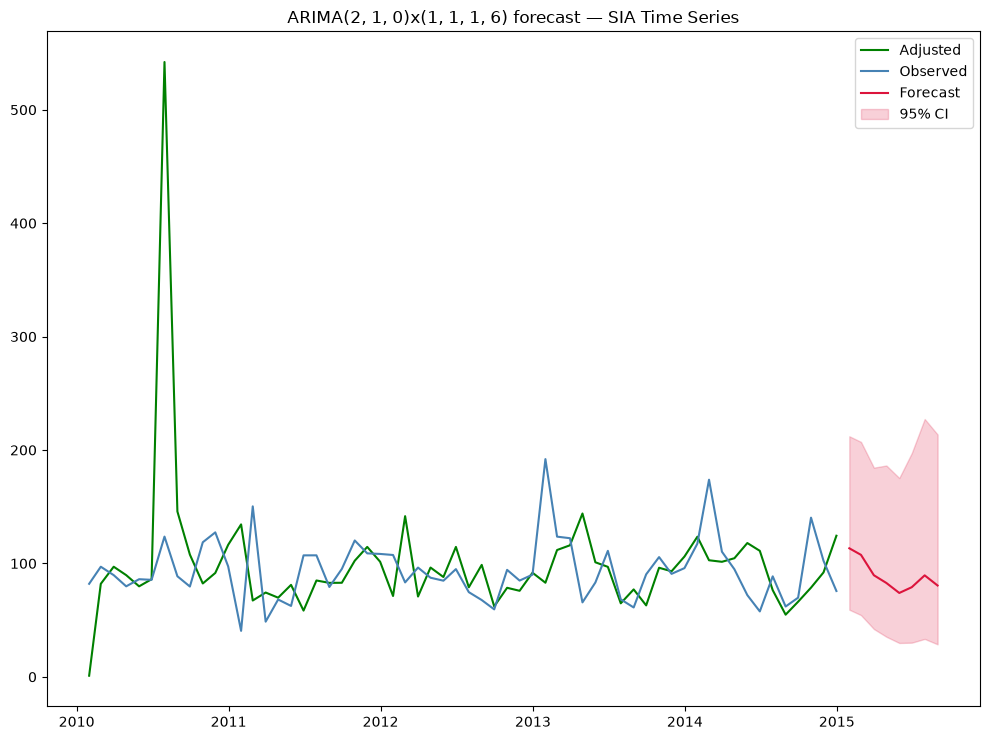

In [39]:
from scipy.special import inv_boxcox
# 5. Forecast 136 periods 
# ---------------------------------------------------------------
steps = 8
fc   = best_model.get_forecast(steps=steps)
mean = fc.predicted_mean
ci   = fc.conf_int(alpha=0.05)

mean   = inv_boxcox(mean, lam)
ci   = inv_boxcox(ci, lam)

fit_val = inv_boxcox(best_model.fittedvalues,lam)

future_idx = pd.date_range(df.index[-1], periods=steps + 1, freq="ME")[1:]

fig, ax = plt.subplots()
ax.plot(fit_val, label="Adjusted", color="green")
ax.plot(df, label="Observed", color="steelblue")
ax.plot(future_idx, mean, label="Forecast", color="crimson")
ax.fill_between(future_idx, ci.iloc[:, 0], ci.iloc[:, 1],
                color="crimson", alpha=0.2, label="95% CI")
ax.set_title("ARIMA(2, 1, 0)x(1, 1, 1, 6) forecast — SIA Time Series")
ax.legend(); plt.tight_layout(); plt.show()

## Por días

In [217]:
df = pd.read_csv('air_pollution.csv', parse_dates=['date'])
df.set_index('date', inplace=True)
df.index = pd.date_range(start="2010-01-02 00:00:00", periods=len(df), freq="h")
df

,pollution_today,dew,temp,press,wnd_dir,wnd_spd,snow,rain
2010-01-02 00:00:00,129.0,-16,-4.0,1020.0,SE,1.79,0,0
2010-01-02 01:00:00,148.0,-15,-4.0,1020.0,SE,2.68,0,0
2010-01-02 02:00:00,159.0,-11,-5.0,1021.0,SE,3.57,0,0
2010-01-02 03:00:00,181.0,-7,-5.0,1022.0,SE,5.36,1,0
2010-01-02 04:00:00,138.0,-7,-5.0,1022.0,SE,6.25,2,0
...,...,...,...,...,...,...,...,...
2014-12-31 19:00:00,8.0,-23,-2.0,1034.0,NW,231.97,0,0
2014-12-31 20:00:00,10.0,-22,-3.0,1034.0,NW,237.78,0,0
2014-12-31 21:00:00,10.0,-22,-3.0,1034.0,NW,242.70,0,0
2014-12-31 22:00:00,8.0,-22,-4.0,1034.0,NW,246.72,0,0


In [218]:
df.drop(['dew', 'temp', 'temp',
       'press', 'wnd_spd','snow','rain','wnd_dir'], axis=1, inplace=True)
df = df.resample('D').mean()
df = df[-300:]
df

,pollution_today
2014-03-07,59.666667
2014-03-08,174.791667
2014-03-09,123.041667
2014-03-10,101.458333
2014-03-11,204.708333
...,...
2014-12-27,238.666667
2014-12-28,197.375000
2014-12-29,159.000000
2014-12-30,46.083333


In [219]:
adf_result = adfuller(df)
adf_result
# Extract values manually from the tuple
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")
print(f"Critical Values: {adf_result[4]}")

ADF Statistic: -8.329308726411194
p-value: 3.402511537795046e-13
Critical Values: {'1%': np.float64(-3.4525611751768914), '5%': np.float64(-2.87132117782556), '10%': np.float64(-2.5719816428028888)}


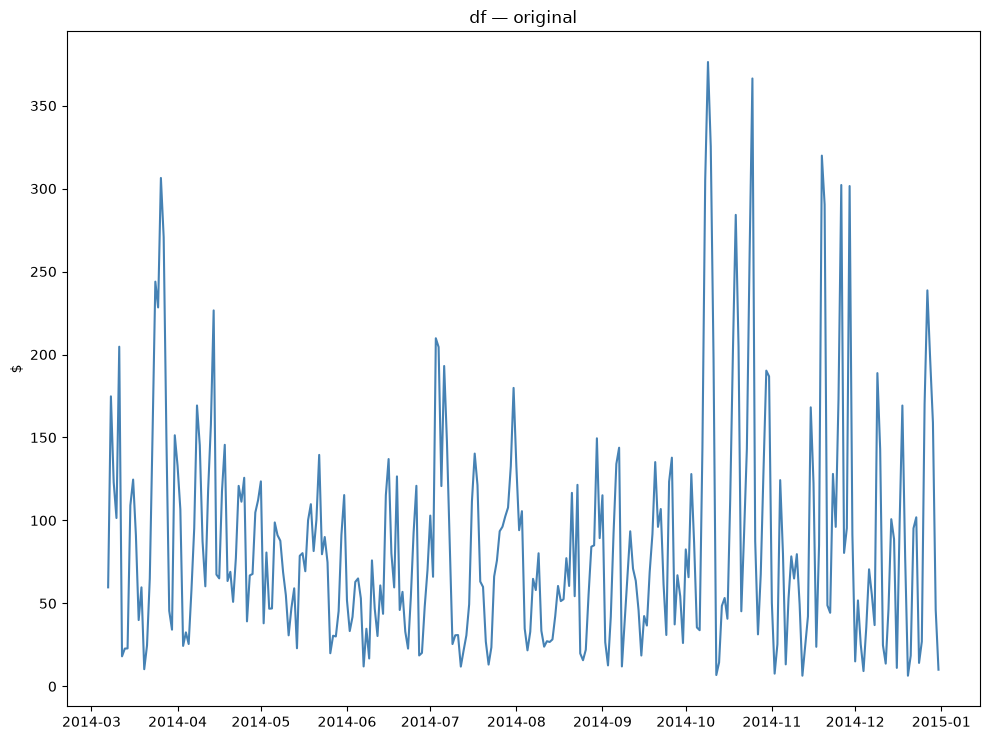

In [220]:
# Create the plot
fig, ax = plt.subplots()
ax.plot(df, color="steelblue")
ax.set_title("df — original")
ax.set_ylabel("$")
plt.tight_layout(); plt.show()

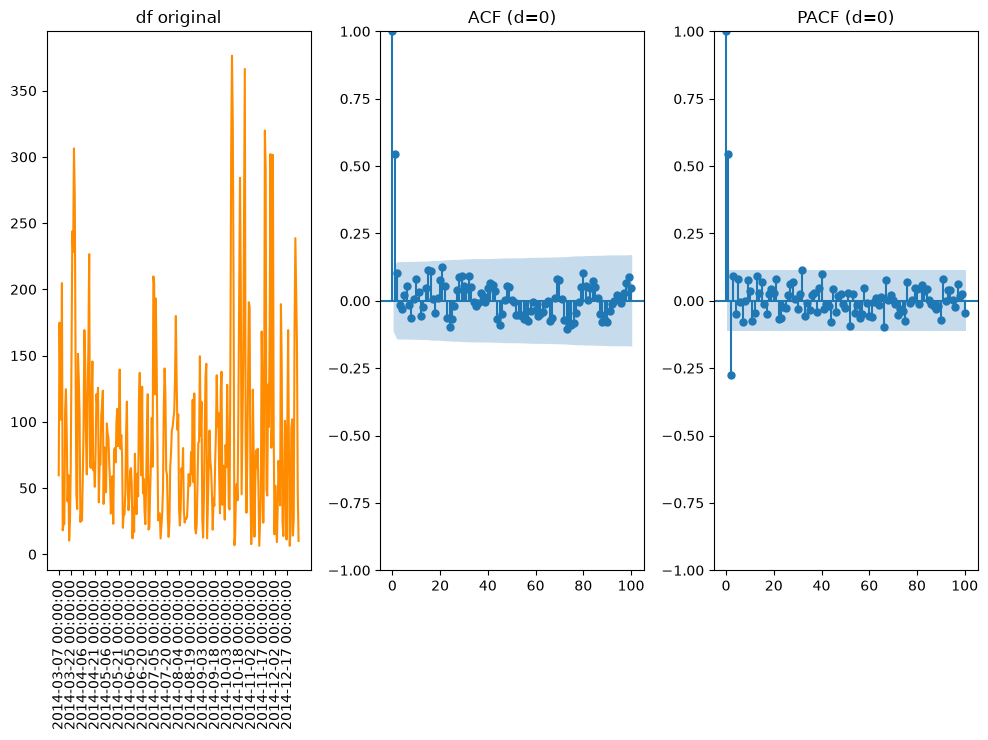

In [221]:
fig, axes = plt.subplots(1, 3)
axes[0].plot(df, color="darkorange")
axes[0].set_title("df original")
axes[0].set_xticks(ticks= df.index[::15],labels=df.index[::15],rotation=90)
plot_acf(df,  ax=axes[1], lags=100, title="ACF (d=0)")
plot_pacf(df, ax=axes[2], lags=100, title="PACF (d=0)", method="ywm")
plt.tight_layout(); plt.show()

In [229]:
import pmdarima as pm

# 'y' is your time series data
# Set 'seasonal=True' and 'm' to your seasonal period (e.g., 12 for monthly)
auto_model = pm.auto_arima(
    df,
    seasonal=True, m=7,
    test='adf',              # Use ADF test for stationarity
    stepwise=True,           # Use stepwise search to save time
    trace=True,              # Print the search progress
    information_criterion='bic', # Or 'bic',
    start_p=0, start_q=0, start_P=0,start_Q=0,
    max_p=3, max_q=3, d=1, D=1, max_P=3, max_Q=3
)

print(auto_model.summary())

Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,1,0)[7]             : BIC=3474.666, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[7]             : BIC=3401.819, Time=0.09 sec
 ARIMA(0,1,1)(0,1,1)[7]             : BIC=3305.961, Time=0.17 sec
 ARIMA(0,1,1)(0,1,0)[7]             : BIC=3480.341, Time=0.03 sec
 ARIMA(0,1,1)(1,1,1)[7]             : BIC=3310.024, Time=0.43 sec
 ARIMA(0,1,1)(0,1,2)[7]             : BIC=inf, Time=0.25 sec
 ARIMA(0,1,1)(1,1,0)[7]             : BIC=3401.542, Time=0.08 sec
 ARIMA(0,1,1)(1,1,2)[7]             : BIC=inf, Time=0.62 sec
 ARIMA(0,1,0)(0,1,1)[7]             : BIC=3300.558, Time=0.07 sec
 ARIMA(0,1,0)(1,1,1)[7]             : BIC=3304.797, Time=0.18 sec
 ARIMA(0,1,0)(0,1,2)[7]             : BIC=3304.579, Time=0.32 sec
 ARIMA(0,1,0)(1,1,0)[7]             : BIC=3396.249, Time=0.06 sec
 ARIMA(0,1,0)(1,1,2)[7]             : BIC=3310.065, Time=0.49 sec
 ARIMA(1,1,0)(0,1,1)[7]             : BIC=3306.158, Time=0.21 sec
 ARIMA(1,1,1)(0,1,1)[7]             : BIC=i

In [230]:
import statsmodels.api as sm
best_model = sm.tsa.SARIMAX(df, order=(0, 1, 0), trend='c',
                seasonal_order=(0, 1, 1, 7)).fit()
print(best_model .summary())

                                      SARIMAX Results                                      
Dep. Variable:                     pollution_today   No. Observations:                  300
Model:             SARIMAX(0, 1, 0)x(0, 1, [1], 7)   Log Likelihood               -1644.593
Date:                             Fri, 09 Oct 2026   AIC                           3295.186
Time:                                     15:16:20   BIC                           3306.216
Sample:                                 03-07-2014   HQIC                          3299.604
                                      - 12-31-2014                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0574      0.378     -0.152      0.879      -0.799       0.684
ma.S.L7       -0.9306      

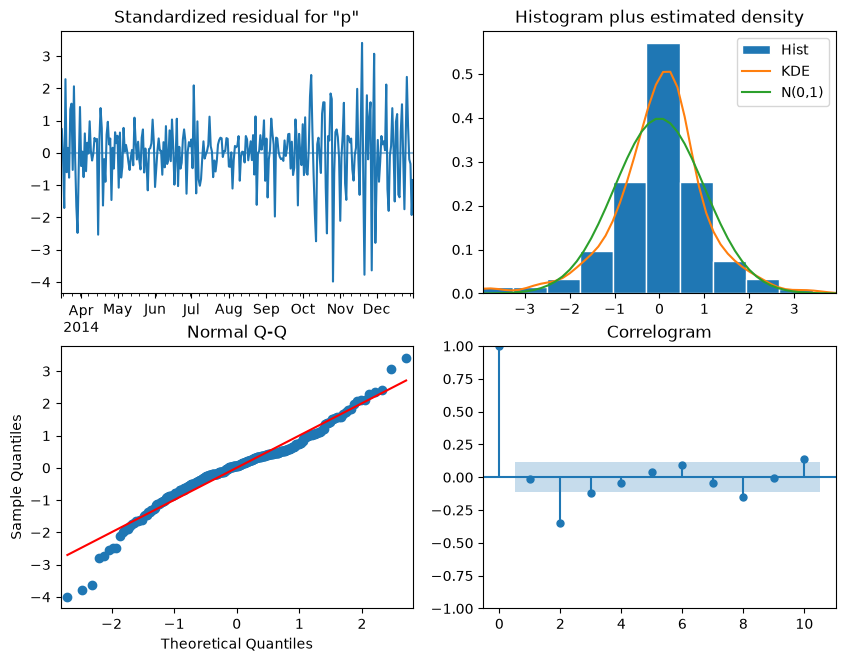

In [231]:
best_model.plot_diagnostics()
plt.show()

In [232]:
import pmdarima as pm

# 'y' is your time series data
# Set 'seasonal=True' and 'm' to your seasonal period (e.g., 12 for monthly)
auto_model = pm.auto_arima(
    df,
    seasonal=False, m=6,
    test='adf',              # Use ADF test for stationarity
    stepwise=True,           # Use stepwise search to save time
    trace=True,              # Print the search progress
    information_criterion='bic', # Or 'bic',
    start_p=0, start_q=0, start_P=0,start_Q=0,
    max_p=3, max_q=3, d=0, D=0, max_P=0, max_Q=0
)

print(auto_model.summary())

Performing stepwise search to minimize bic
 ARIMA(0,0,0)(0,0,0)[0]             : BIC=3680.595, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : BIC=3338.746, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : BIC=3454.692, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0]             : BIC=3342.377, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0]             : BIC=3339.214, Time=0.06 sec
 ARIMA(2,0,1)(0,0,0)[0]             : BIC=3338.331, Time=0.13 sec
 ARIMA(3,0,1)(0,0,0)[0]             : BIC=3287.156, Time=0.18 sec
 ARIMA(3,0,0)(0,0,0)[0]             : BIC=3323.074, Time=0.06 sec
 ARIMA(3,0,2)(0,0,0)[0]             : BIC=3289.492, Time=0.22 sec
 ARIMA(2,0,2)(0,0,0)[0]             : BIC=inf, Time=0.17 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : BIC=3284.320, Time=0.09 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : BIC=3277.426, Time=0.19 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : BIC=3272.096, Time=0.12 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : BIC=3273.775, Time=0.08 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : 

In [233]:
import statsmodels.api as sm
best_model = sm.tsa.SARIMAX(df, order=(0, 0, 2), trend='c',
                seasonal_order=(0, 0, 0, 0)).fit()
print(best_model .summary())

                               SARIMAX Results                                
Dep. Variable:        pollution_today   No. Observations:                  300
Model:               SARIMAX(0, 0, 2)   Log Likelihood               -1624.517
Date:                Fri, 09 Oct 2026   AIC                           3257.035
Time:                        15:17:06   BIC                           3271.850
Sample:                    03-07-2014   HQIC                          3262.964
                         - 12-31-2014                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     86.9301      7.429     11.702      0.000      72.370     101.490
ma.L1          0.7313      0.049     15.016      0.000       0.636       0.827
ma.L2          0.1576      0.045      3.497      0.0

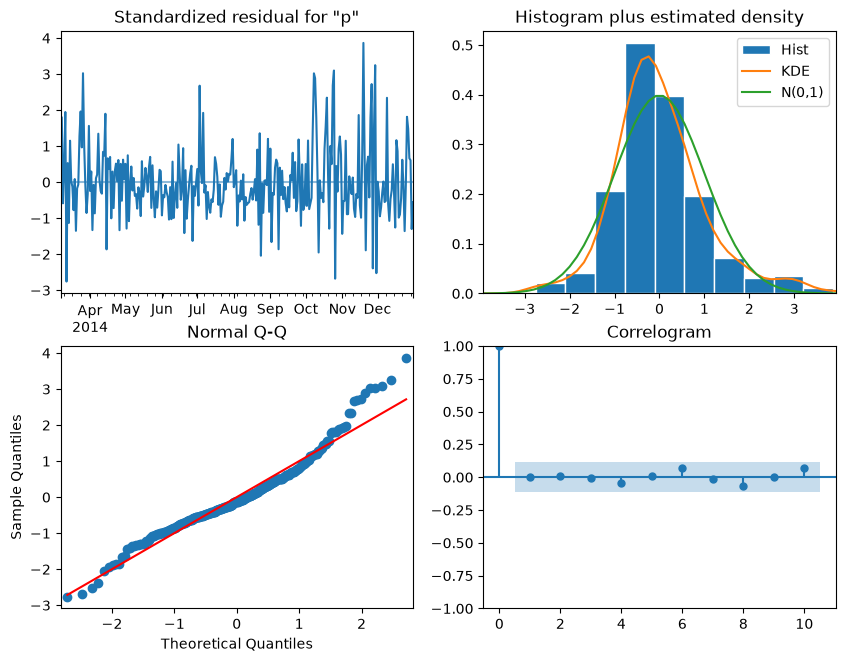

In [234]:
best_model.plot_diagnostics()
plt.show()

In [235]:
print(acorr_ljungbox(best_model.resid[1:], lags=[1, 2,3,4,5,6,7,8,9,10,15], return_df=True)) # deben ser mayores a 0.05

     lb_stat  lb_pvalue
1   0.002854   0.957397
2   0.033025   0.983623
3   0.035229   0.998260
4   0.497129   0.973780
5   0.499475   0.992142
6   1.906880   0.928060
7   2.004933   0.959567
8   3.249759   0.917720
9   3.250020   0.953552
10  4.830704   0.902196
15  9.089252   0.872805


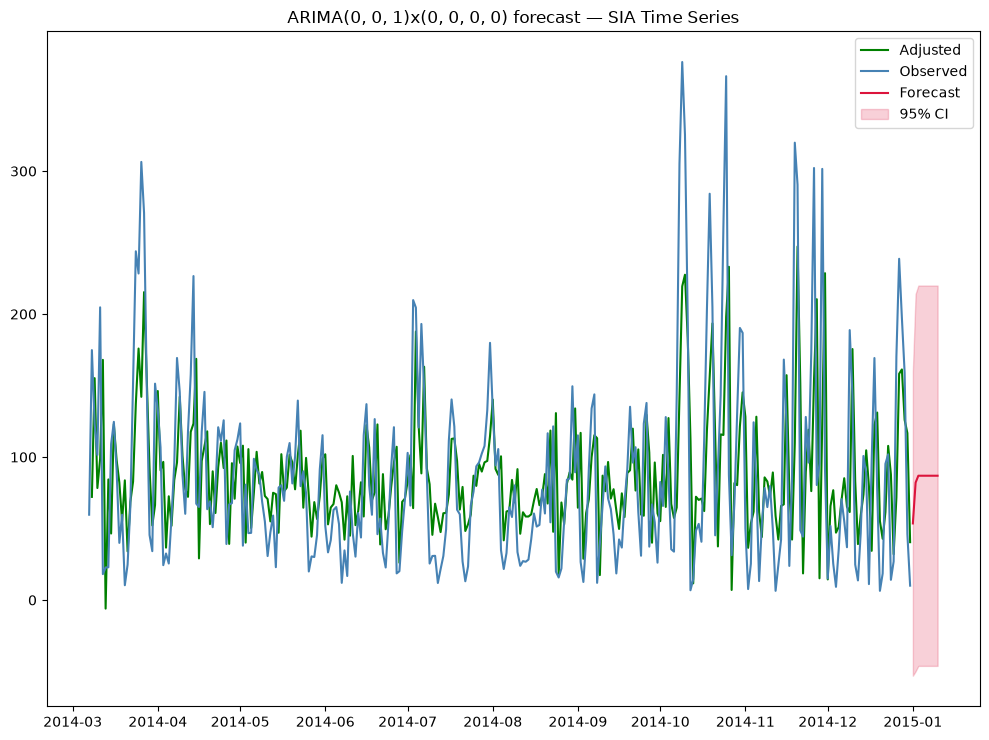

In [236]:
# 5. Forecast 136 periods 
# ---------------------------------------------------------------
steps = 10
fc   = best_model.get_forecast(steps=steps)
mean = fc.predicted_mean
ci   = fc.conf_int(alpha=0.05)

future_idx = pd.date_range(df.index[-1], periods=steps + 1, freq="D")[1:]

fig, ax = plt.subplots()

ax.plot(best_model.fittedvalues[1:],label="Adjusted", color="green")
ax.plot(df, label="Observed", color="steelblue")
ax.plot(future_idx, mean, label="Forecast", color="crimson")
ax.fill_between(future_idx, ci.iloc[:, 0], ci.iloc[:, 1],
                color="crimson", alpha=0.2, label="95% CI")
ax.set_title("ARIMA(0, 0, 1)x(0, 0, 0, 0) forecast — SIA Time Series")
ax.legend(); plt.tight_layout(); plt.show()

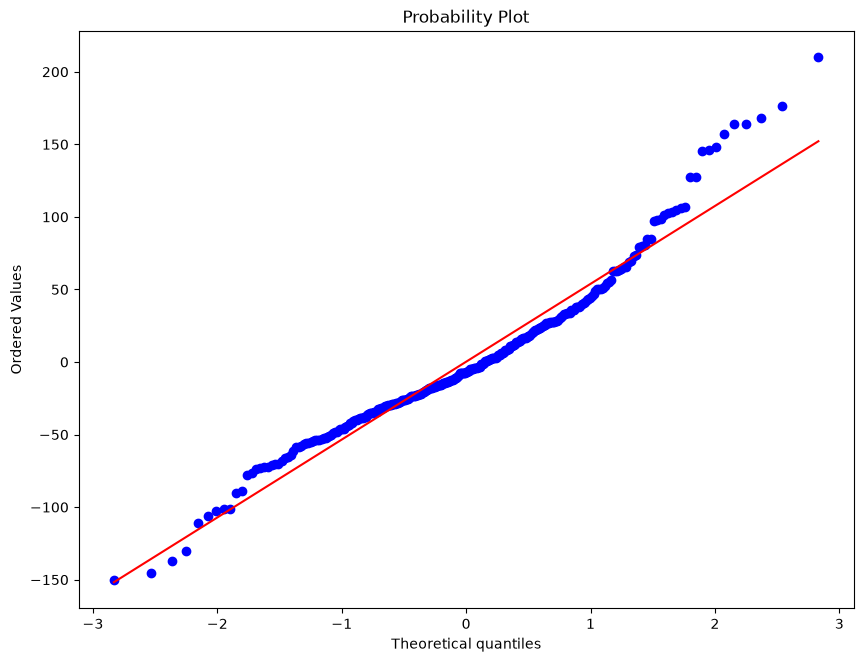

In [237]:
import scipy.stats as stats
stats.probplot(best_model.resid[1:],dist='norm', plot=plt)
plt.show()

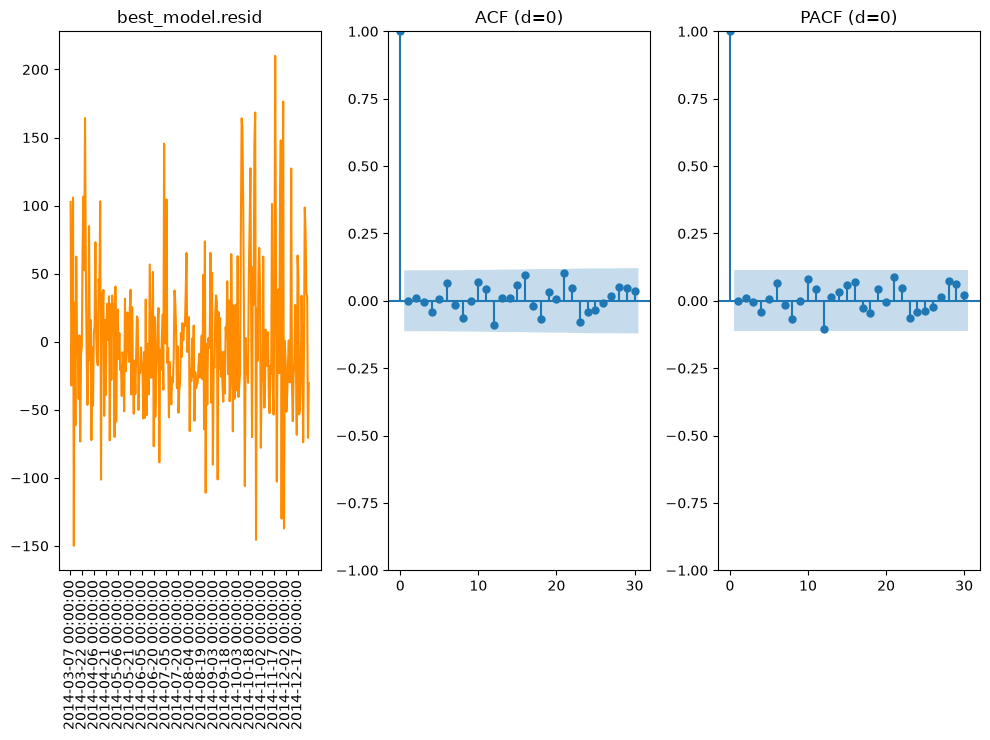

In [238]:
fig, axes = plt.subplots(1, 3)
axes[0].plot(best_model.resid[1:], color="darkorange")
axes[0].set_title("best_model.resid")
axes[0].set_xticks(ticks= best_model.resid.index[::15],labels=best_model.resid.index[::15],rotation=90)
plot_acf(best_model.resid,  ax=axes[1], lags=30, title="ACF (d=0)")
plot_pacf(best_model.resid, ax=axes[2], lags=30, title="PACF (d=0)", method="ywm")
plt.tight_layout(); plt.show()

## Prophet

In [157]:
!pip install prophet

In [158]:
import pandas as pd
from prophet import Prophet

In [159]:
df

,pollution_today
2014-03-07,59.666667
2014-03-08,174.791667
2014-03-09,123.041667
2014-03-10,101.458333
2014-03-11,204.708333
...,...
2014-12-27,238.666667
2014-12-28,197.375000
2014-12-29,159.000000
2014-12-30,46.083333


In [160]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 300 entries, 2014-03-07 to 2014-12-31
Freq: D
Data columns (total 1 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pollution_today  300 non-null    float64
dtypes: float64(1)
memory usage: 4.7 KB


In [161]:
df.index

DatetimeIndex(['2014-03-07', '2014-03-08', '2014-03-09', '2014-03-10',
               '2014-03-11', '2014-03-12', '2014-03-13', '2014-03-14',
               '2014-03-15', '2014-03-16',
               ...
               '2014-12-22', '2014-12-23', '2014-12-24', '2014-12-25',
               '2014-12-26', '2014-12-27', '2014-12-28', '2014-12-29',
               '2014-12-30', '2014-12-31'],
              dtype='datetime64[ns]', length=300, freq='D')

In [162]:
df["Date"]=df.index
profet_df = df[['Date','pollution_today']]
profet_df

,Date,pollution_today
2014-03-07,2014-03-07,59.666667
2014-03-08,2014-03-08,174.791667
2014-03-09,2014-03-09,123.041667
2014-03-10,2014-03-10,101.458333
2014-03-11,2014-03-11,204.708333
...,...,...
2014-12-27,2014-12-27,238.666667
2014-12-28,2014-12-28,197.375000
2014-12-29,2014-12-29,159.000000
2014-12-30,2014-12-30,46.083333


In [163]:
profet_df.columns=['ds','y']

In [164]:
# 2. Instantiate and fit the model
model = Prophet(yearly_seasonality=False,  weekly_seasonality=True, daily_seasonality=True )
model.fit(profet_df)

# 3. Create a future dataframe extending into the future (e.g., 30 days)
future = model.make_future_dataframe(periods=30, freq='D')

# 4. Generate forecasts
forecast = model.predict(future)

# 5. Inspect key forecast results
# yhat: predicted value, yhat_lower/yhat_upper: uncertainty bounds
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

13:47:09 - cmdstanpy - INFO - Chain [1] start processing
13:47:10 - cmdstanpy - INFO - Chain [1] done processing


            ds        yhat  yhat_lower  yhat_upper
325 2015-01-26   83.078392    1.153898  168.620083
326 2015-01-27   87.999702    5.914593  173.896769
327 2015-01-28   97.291971   11.068418  183.680519
328 2015-01-29  108.684741   21.412417  194.195507
329 2015-01-30  100.309676   14.422455  185.508957
          ds        yhat  yhat_lower  yhat_upper
0 2014-03-07   93.257072    0.767270  180.697872
1 2014-03-08  100.208702   13.197679  183.481623
2 2014-03-09   84.692703    4.667826  170.732480
3 2014-03-10   76.073576   -7.902991  161.780943
4 2014-03-11   80.850294   -5.133452  169.701803


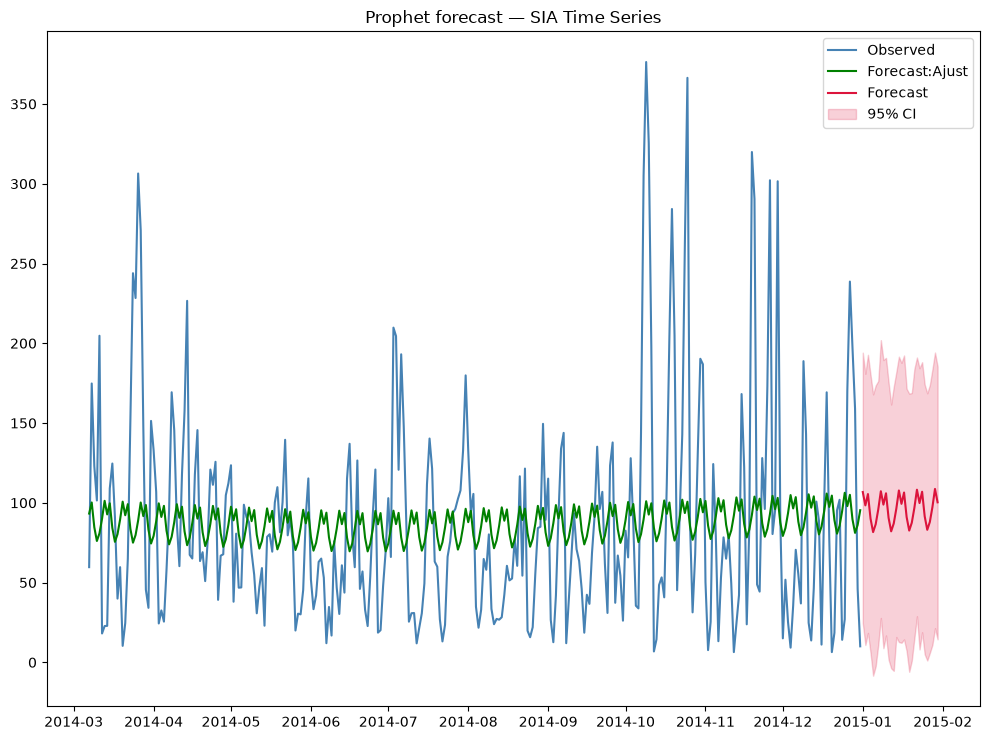

In [165]:
# 5. Forecast 136 periods 
# ---------------------------------------------------------------
steps = 30

mean = forecast['yhat']
ajust = mean.loc[:len(profet_df)-1]
mean = mean.loc[len(profet_df):]
ci_low   = forecast['yhat_lower']
ci_low = ci_low.loc[len(profet_df):]
ci_up   = forecast['yhat_upper']
ci_up = ci_up.loc[len(profet_df):]

future_idx = pd.date_range(profet_df.index[-1], periods=steps + 1, freq="D")[1:]
present_idx = pd.date_range(profet_df.index[0], periods=len(profet_df), freq="D")[0:]

fig, ax = plt.subplots()
ax.plot(profet_df['y'], label="Observed", color="steelblue")
ax.plot(present_idx, ajust, label="Forecast:Ajust", color="green")
ax.plot(future_idx, mean, label="Forecast", color="crimson")
ax.fill_between(future_idx, ci_low, ci_up,
                color="crimson", alpha=0.2, label="95% CI")
ax.set_title("Prophet forecast — SIA Time Series")
ax.legend(); plt.tight_layout(); plt.show()

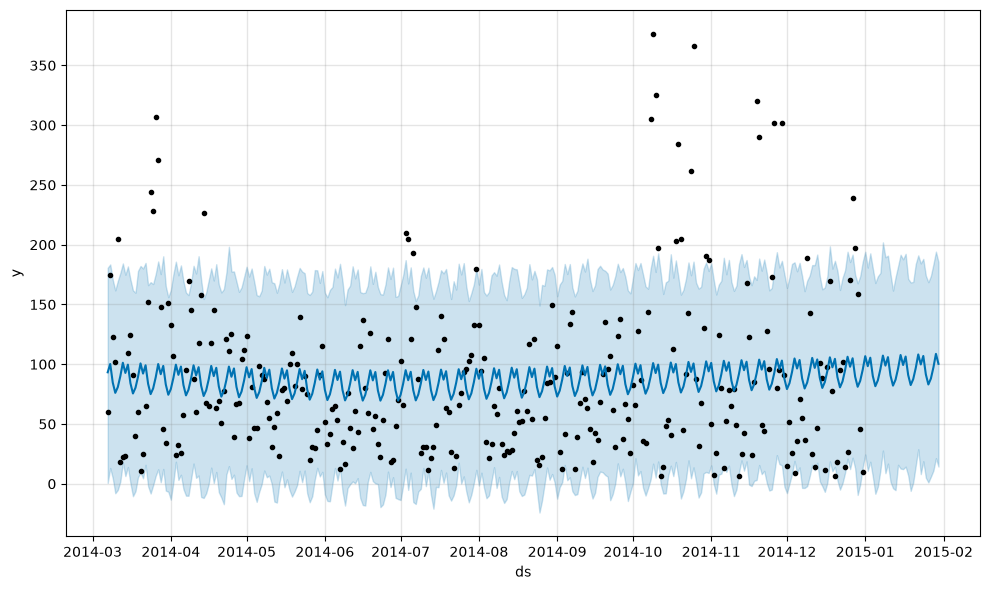

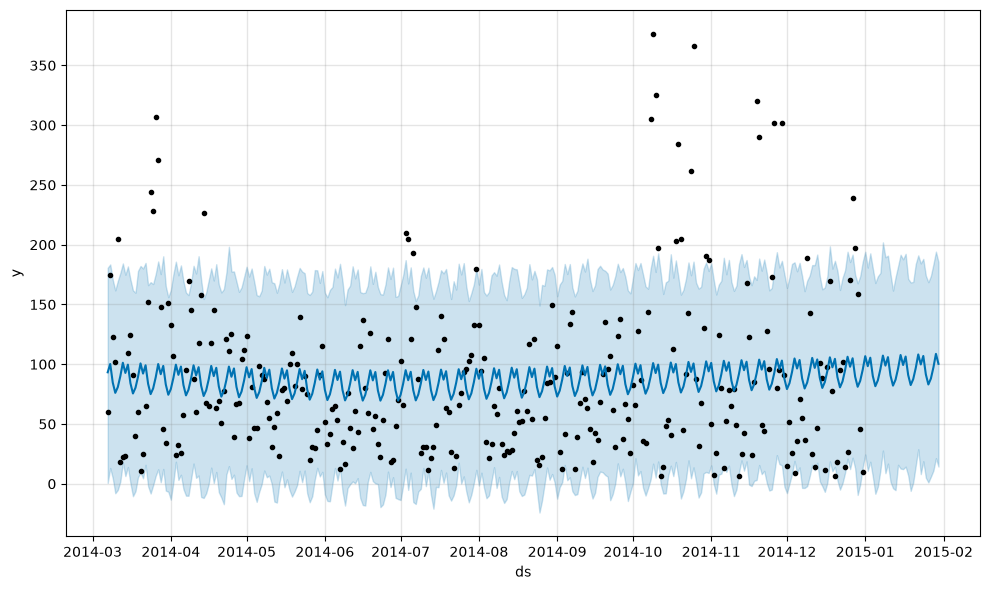

In [166]:
model.plot(forecast)

In [167]:
# 2. Instantiate and fit the model
from prophet.plot import add_changepoints_to_plot
model = Prophet(yearly_seasonality=False,  weekly_seasonality=True, daily_seasonality=False)

# 2. Add your custom seasonality
model.add_seasonality(
    name='quarterly', 
    period=91, #dias de un trimestre
    fourier_order=5 #componentes de análisis de Fourier
)

model.fit(profet_df)

# 3. Create a future dataframe extending into the future (e.g., 30 days)
future = model.make_future_dataframe(periods=30, freq='D')

# 4. Generate forecasts
forecast = model.predict(future)

# 5. Inspect key forecast results
# yhat: predicted value, yhat_lower/yhat_upper: uncertainty bounds
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

13:47:44 - cmdstanpy - INFO - Chain [1] start processing
13:47:44 - cmdstanpy - INFO - Chain [1] done processing


            ds        yhat  yhat_lower  yhat_upper
325 2015-01-26  118.821267   37.932238  197.435031
326 2015-01-27  123.367865   44.260135  207.057103
327 2015-01-28  130.119434   46.071279  217.303708
328 2015-01-29  137.110298   62.783405  220.046071
329 2015-01-30  122.460551   36.501810  204.434861
          ds       yhat  yhat_lower  yhat_upper
0 2014-03-07  76.936695   -4.768524  159.958913
1 2014-03-08  82.385284   -1.515089  161.743425
2 2014-03-09  65.339184  -14.627689  142.246220
3 2014-03-10  55.018728  -24.259160  140.788126
4 2014-03-11  58.024063  -24.352454  137.965158


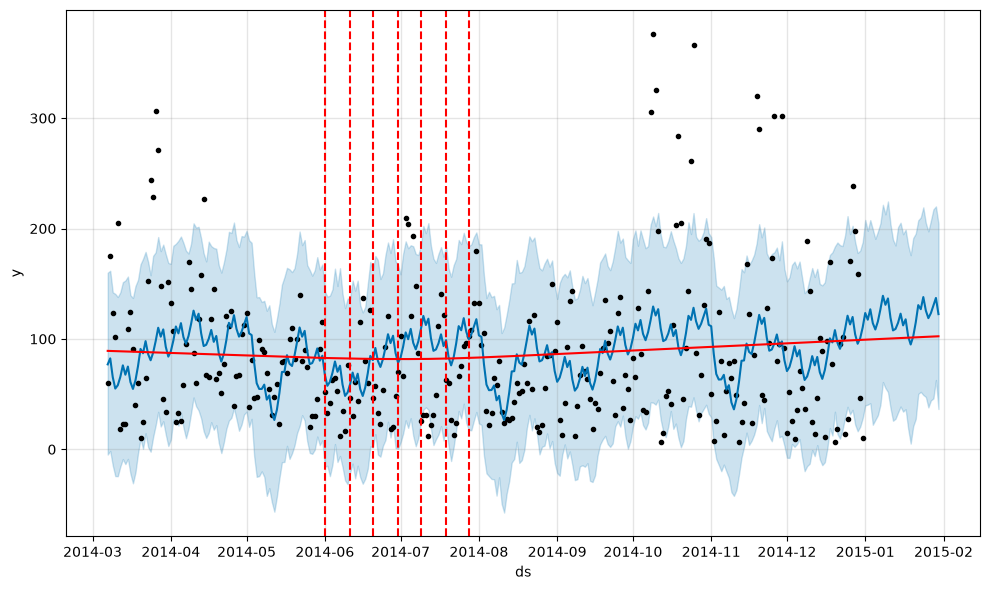

In [168]:
fig = model.plot(forecast)
a = add_changepoints_to_plot(fig.gca(), model, forecast)
plt.show()

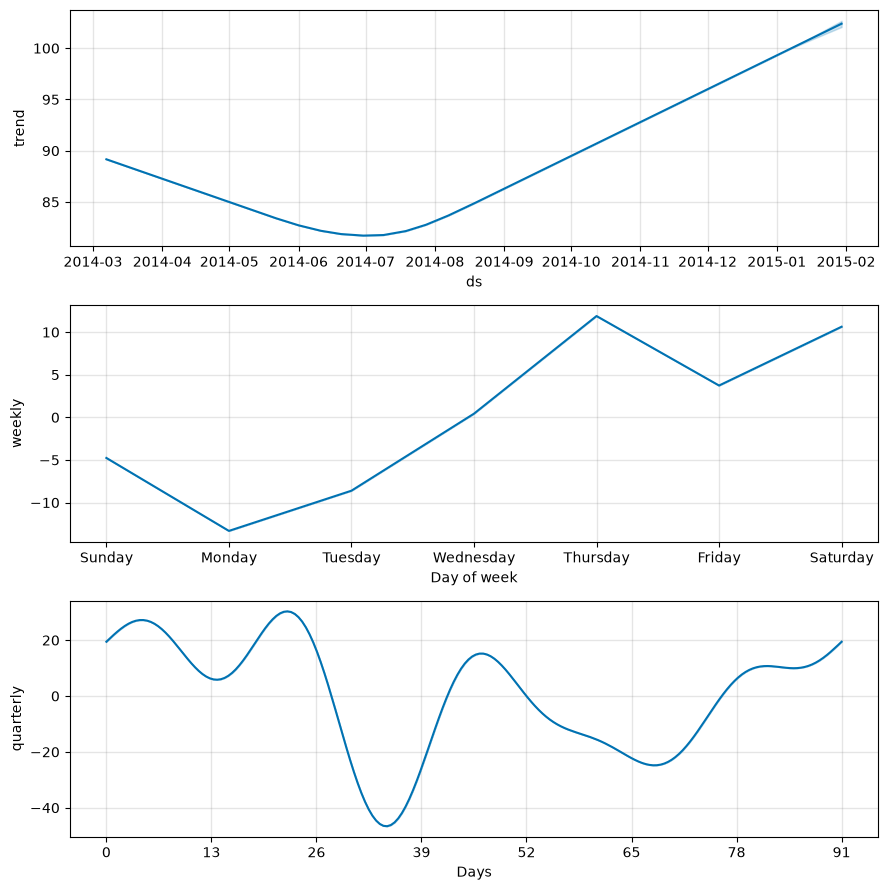

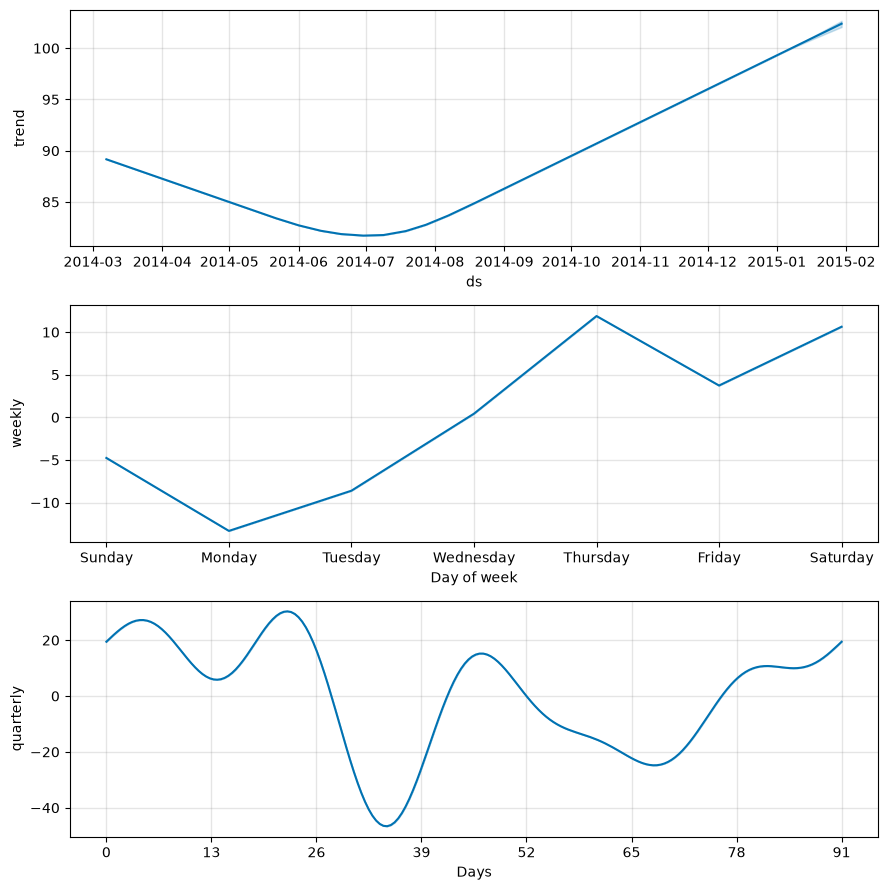

In [169]:
model.plot_components(forecast)

## Statistical Model Comparison Dashboard

In [247]:
train_size = int( len (df)*0.8 )

In [248]:
train = df[:train_size]
test = df[train_size:]

In [249]:
test.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 60 entries, 2014-11-02 to 2014-12-31
Freq: D
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pollution_today  60 non-null     float64       
 1   Date             60 non-null     datetime64[ns]
dtypes: datetime64[ns](1), float64(1)
memory usage: 1.4 KB


<Axes: >

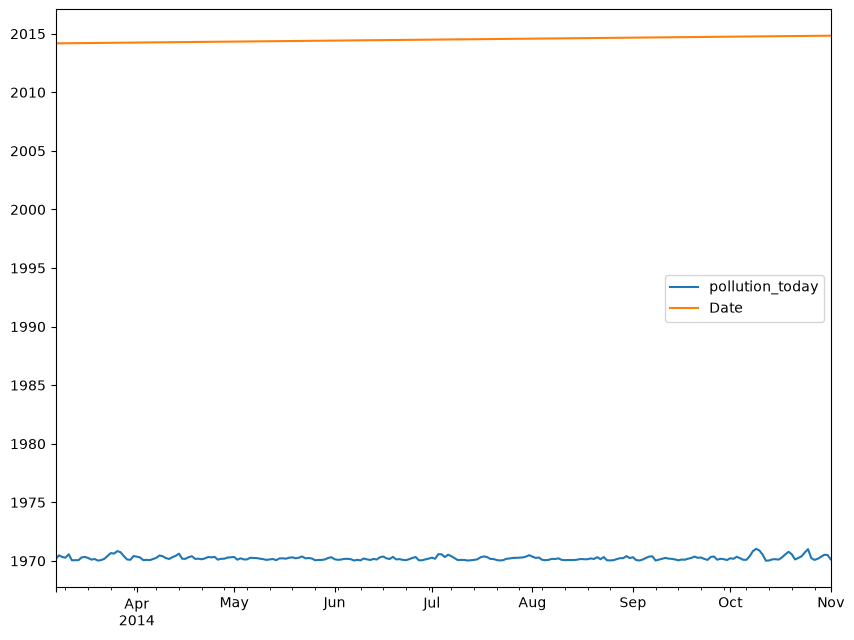

In [250]:
train.plot()

## Baseline

In [251]:
actual_values = test['pollution_today']

In [252]:
baseline_pred = [train['pollution_today'].iloc[-1]]*len(test)
baseline_pred = actual_values.shift(1)

In [253]:
baseline_pred[0] = actual_values.mean()


In [254]:
import random

# Set the seed value
random.seed(42)


## Holt Winters

In [255]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [256]:
# Model assignment for a monthly time series (seasonal_periods=12)
hw = ExponentialSmoothing(
    train['pollution_today'], 
    trend='mul',          # Can be 'add' or 'mul'
    seasonal='mul',       # Can be 'add' or 'mul'
    seasonal_periods=7  # Number of periods in a complete cycle
)

# Fit the model
hw_fit = hw.fit()

# Forecast the next 12 steps
#C = model_fit.forecast(steps=12)

hw_fitted = hw_fit.forecast(len(test))

## Arima

In [257]:
from statsmodels.tsa.arima.model import ARIMA
arima_model = ARIMA(train['pollution_today'],order=(0,0,2))
# Fit the model
arima_fit = arima_model.fit()
arima_fitted = arima_fit.forecast(len(test))

## Sarima

In [258]:
import statsmodels.api as sm
warnings.filterwarnings("ignore")

sarima_model = sm.tsa.SARIMAX(train['pollution_today'], order=(0, 1, 0), trend='c',
                seasonal_order=(0, 1, 1, 7)).fit()
sarima_fitted = sarima_model.forecast(len(test))

## Profet

In [259]:
df

,pollution_today,Date
2014-03-07,59.666667,2014-03-07
2014-03-08,174.791667,2014-03-08
2014-03-09,123.041667,2014-03-09
2014-03-10,101.458333,2014-03-10
2014-03-11,204.708333,2014-03-11
...,...,...
2014-12-27,238.666667,2014-12-27
2014-12-28,197.375000,2014-12-28
2014-12-29,159.000000,2014-12-29
2014-12-30,46.083333,2014-12-30


In [260]:
df["Date"]=df.index
profet_df = df[['Date','pollution_today']]
profet_df

,Date,pollution_today
2014-03-07,2014-03-07,59.666667
2014-03-08,2014-03-08,174.791667
2014-03-09,2014-03-09,123.041667
2014-03-10,2014-03-10,101.458333
2014-03-11,2014-03-11,204.708333
...,...,...
2014-12-27,2014-12-27,238.666667
2014-12-28,2014-12-28,197.375000
2014-12-29,2014-12-29,159.000000
2014-12-30,2014-12-30,46.083333


In [261]:
profet_df[:train_size]

,Date,pollution_today
2014-03-07,2014-03-07,59.666667
2014-03-08,2014-03-08,174.791667
2014-03-09,2014-03-09,123.041667
2014-03-10,2014-03-10,101.458333
2014-03-11,2014-03-11,204.708333
...,...,...
2014-10-28,2014-10-28,67.541667
2014-10-29,2014-10-29,130.500000
2014-10-30,2014-10-30,190.291667
2014-10-31,2014-10-31,186.833333


In [271]:
from prophet import Prophet

profet_train = profet_df[:train_size]
profet_train.columns = ['ds','y']
profet_model = Prophet()
profet_model_fit = profet_model.fit(profet_train)

future = profet_model.make_future_dataframe(
    periods = len(test),
    freq = "d")

15:32:09 - cmdstanpy - INFO - Chain [1] start processing
15:32:09 - cmdstanpy - INFO - Chain [1] done processing


In [272]:
forecast = profet_model.predict(future)
# yhat: predicted value, yhat_lower/yhat_upper: uncertainty bounds
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())


            ds        yhat  yhat_lower  yhat_upper
295 2014-12-27  117.868688   43.530071  199.890294
296 2014-12-28  106.612463   23.668281  184.297364
297 2014-12-29  100.875679   21.429072  176.848773
298 2014-12-30  100.949153   20.777186  181.954472
299 2014-12-31  107.853298   28.341425  187.704836
          ds       yhat  yhat_lower  yhat_upper
0 2014-03-07  93.641449   13.514099  169.423369
1 2014-03-08  90.272483   11.283923  166.854438
2 2014-03-09  78.793848    2.843186  159.061586
3 2014-03-10  72.834654   -5.713884  152.335559
4 2014-03-11  72.685717  -11.000970  152.156225


In [273]:
prophet_pred = forecast['yhat'].iloc[-len(test):].values

In [283]:
comparison_df = pd.DataFrame({'Actual': actual_values.values, 'Baseline' : baseline_pred, 'Holt_Winters' : hw_fitted.values,
                              'Arima': arima_fitted.values, 'Sarima': sarima_fitted.values, 'Prophet': prophet_pred})

In [284]:
comparison_df

,Actual,Baseline,Holt_Winters,Arima,Sarima,Prophet
2014-11-02,7.666667,89.441667,25.410829,36.191303,-4.312378,95.349726
2014-11-03,25.375000,7.666667,15.463588,60.382229,-29.466078,89.612942
2014-11-04,124.291667,25.375000,22.562857,86.074836,-35.559304,89.686416
2014-11-05,79.875000,124.291667,24.708509,86.074836,-6.197697,96.590561
2014-11-06,13.250000,79.875000,29.031027,86.074836,28.762283,118.432967
2014-11-07,52.875000,13.250000,31.328199,86.074836,44.687594,111.160349
2014-11-08,78.333333,52.875000,20.383506,86.074836,33.655972,108.013793
2014-11-09,65.000000,78.333333,9.106151,86.074836,-21.043637,96.757568
2014-11-10,79.666667,65.000000,5.541487,86.074836,-46.292902,91.020784
2014-11-11,49.333333,79.666667,8.085560,86.074836,-52.481694,91.094258


In [285]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
import numpy as np

def evaluate(df_real, df_y):
    mae = mean_absolute_error(df_real, df_y)
    mape = mean_absolute_percentage_error(df_real, df_y)
    rmse = np.sqrt( mean_squared_error (df_real, df_y) )
    return mae, mape, rmse

In [286]:
for col in comparison_df[1:]:
    mae, mape, rmse = evaluate(comparison_df['Actual'], comparison_df[col])
    print (col , mae, mape, rmse)

Actual 0.0 0.0 0.0
Baseline 67.32888888888888 1.7059462715662996 89.82967869034772
Holt_Winters 86.25434942698277 0.9548899466469718 117.65665966463597
Arima 58.63314267049573 1.8161227039628225 78.81687056518925
Sarima 157.21927025520029 3.0431111799270414 185.6361703049541
Prophet 66.70453143306877 2.502282855560127 81.92619556246795


In [287]:
!pip install dash

In [290]:
import dash
from dash import dcc, html, dash_table, Input, Output
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ------------------------------------------------------------------
# 1. Build comparison_df (your code, fixed slicing)
# ------------------------------------------------------------------
comparison_df = pd.DataFrame({
    'Actual':       actual_values.values,
    'Baseline':     baseline_pred,
    'Holt_Winters': hw_fitted.values,
    'Arima':        arima_fitted.values,
    'Sarima':       sarima_fitted.values,
    'Prophet':      prophet_pred,
})

# ------------------------------------------------------------------
# 2. Evaluate models
# ------------------------------------------------------------------
def evaluate(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, mape, rmse

model_cols = [c for c in comparison_df.columns if c != 'Actual']
metrics_rows = []
for col in model_cols:
    mae, mape, rmse = evaluate(comparison_df['Actual'], comparison_df[col])
    metrics_rows.append({'Model': col, 'MAE': mae, 'MAPE (%)': mape, 'RMSE': rmse})

metrics_df = pd.DataFrame(metrics_rows)

# Long format for bar chart
metrics_long = metrics_df.melt(id_vars='Model',
                               var_name='Metric',
                               value_name='Value')

# ------------------------------------------------------------------
# 3. Dash app
# ------------------------------------------------------------------
app = dash.Dash(__name__)
app.title = "Forecast Comparison Dashboard"

app.layout = html.Div([
    html.H1("📊 Forecast Model Comparison",
            style={'textAlign': 'center', 'marginBottom': '10px'}),

    # ---- Model selector ----
    html.Div([
        html.Label("Select models to display:", style={'fontWeight': 'bold'}),
        dcc.Checklist(
            id='model-selector',
            options=[{'label': m, 'value': m} for m in model_cols],
            value=model_cols,           # all selected by default
            inline=True,
            style={'marginTop': '8px'}
        ),
    ], style={'padding': '15px', 'borderBottom': '1px solid #ddd'}),

    # ---- Time series plot ----
    dcc.Graph(id='ts-plot', style={'height': '520px'}),

    # ---- Metrics row ----
    html.Div([
        html.Div([
            html.H3("Metrics by Model", style={'textAlign': 'center'}),
            dcc.Graph(id='metrics-bar', style={'height': '420px'}),
        ], style={'width': '58%', 'display': 'inline-block', 'verticalAlign': 'top'}),

        html.Div([
            html.H3("Metrics Table", style={'textAlign': 'center'}),
            dash_table.DataTable(
                id='metrics-table',
                columns=[{'name': c, 'id': c} for c in metrics_df.columns],
                data=metrics_df.round(3).to_dict('records'),
                sort_action='native',
                style_cell={'textAlign': 'center', 'padding': '8px'},
                style_header={'backgroundColor': '#f4f4f4', 'fontWeight': 'bold'},
                style_data_conditional=[
                    {'if': {'row_index': 'odd'}, 'backgroundColor': '#fafafa'}
                ],
            ),
            html.Br(),
            html.H4("🏆 Best Model per Metric", style={'textAlign': 'center'}),
            html.Div(id='best-models', style={'textAlign': 'center', 'lineHeight': '1.8'}),
        ], style={'width': '38%', 'display': 'inline-block',
                  'verticalAlign': 'top', 'paddingLeft': '2%'}),
    ], style={'padding': '10px'}),
], style={'fontFamily': 'Arial, sans-serif', 'maxWidth': '1400px', 'margin': 'auto'})


# ------------------------------------------------------------------
# 4. Callbacks
# ------------------------------------------------------------------
@app.callback(
    Output('ts-plot', 'figure'),
    Input('model-selector', 'value'),
)
def update_ts(selected_models):
    fig = go.Figure()

    # Actual line — thick and dark
    fig.add_trace(go.Scatter(
        x=comparison_df.index,
        y=comparison_df['Actual'],
        name='Actual',
        mode='lines',
        line=dict(color='black', width=2.5),
    ))

    colors = px.colors.qualitative.Plotly
    for i, m in enumerate(selected_models or []):
        fig.add_trace(go.Scatter(
            x=comparison_df.index,
            y=comparison_df[m],
            name=m,
            mode='lines',
            line=dict(width=1.6, color=colors[i % len(colors)]),
            opacity=0.85,
        ))

    fig.update_layout(
        title='Actual vs Forecasts over Time',
        xaxis_title='Time',
        yaxis_title='Value',
        hovermode='x unified',
        legend=dict(orientation='h', yanchor='bottom', y=1.02),
        margin=dict(l=40, r=20, t=80, b=40),
    )
    return fig


@app.callback(
    Output('metrics-bar', 'figure'),
    Output('best-models', 'children'),
    Input('model-selector', 'value'),
)
def update_metrics(selected_models):
    # ---- Bar chart ----
    filtered = metrics_long[metrics_long['Model'].isin(selected_models or [])]
    fig = px.bar(
        filtered, x='Model', y='Value', color='Metric',
        barmode='group',
        text_auto='.2f',
        color_discrete_sequence=px.colors.qualitative.Set2,
    )
    fig.update_layout(
        xaxis_title='', yaxis_title='Value',
        legend=dict(orientation='h', yanchor='bottom', y=1.02),
        margin=dict(l=20, r=20, t=20, b=20),
    )

    # ---- Best per metric ----
    sub = metrics_df[metrics_df['Model'].isin(selected_models or [])]
    if sub.empty:
        return fig, "No models selected."

    best_mae  = sub.loc[sub['MAE'].idxmin(),  'Model']
    best_mape = sub.loc[sub['MAPE (%)'].idxmin(), 'Model']
    best_rmse = sub.loc[sub['RMSE'].idxmin(), 'Model']

    best = html.Div([
        html.Div(f"🥇 Lowest MAE:  {best_mae}"),
        html.Div(f"🥇 Lowest MAPE: {best_mape}"),
        html.Div(f"🥇 Lowest RMSE: {best_rmse}"),
    ])
    return fig, best


if __name__ == '__main__':
    #app.run(debug=True)
    app.run(debug=True, port=8051)